# Assess Electrical Stimulation Selectivity

In [1]:
%reload_ext autoreload
%autoreload 2

# Imports
import numpy as np
import visionloader as vl
import matplotlib.pyplot as plt
import os
import matplotlib.cm as cm
from tqdm import tqdm
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

import src.sigmoid as sig
import src.eilib as eil

In [3]:
# piece = '2023-10-30-1'
# analysis_base = f"/Volumes/Analysis/{piece}/RETINA"
# pp_base = analysis_base
# gsort_base = analysis_base
# pickle_path_base = "gsort_single_v2"

# wnoise = 'data006'
# estim = 'data007'
# cell_types = ['ON alpha', 'OFF alpha']

# wnoise_path = os.path.join(analysis_base, wnoise)
# pp_path = os.path.join(pp_base, estim)
# gsort_path = os.path.join(gsort_base, "gsort", estim)

In [2]:
piece = '2024-07-18-0'
analysis_base = f"/Volumes/Stream/Analysis/RETINA/{piece}/"
pp_base = analysis_base
gsort_base = analysis_base
pickle_path_base = "gsort_single_v2"

wnoise = 'data001'
estim = 'data002'
cell_types = ['ON alpha', 'OFF alpha']

wnoise_path = os.path.join(analysis_base, wnoise)
pp_path = os.path.join(pp_base, estim)
gsort_path = os.path.join(gsort_base, "gsort", estim)

In [3]:
amplitudes = np.array([0.09375, 0.1875, 0.28125, 0.375, 0.46875, 0.5625, 0.65625, 0.75, 0.84375, 0.9375,
        1.03125, 1.125, 1.21875, 1.3125, 1.40625, 1.5, 1.59375, 1.6875, 1.78125, 1.875, 1.96875,
        2.0625, 2.15625, 2.25, 2.34375, 2.4375, 2.53125, 2.625, 2.71875, 2.8125, 2.90625, 3.0,
        3.09375, 3.1875, 3.28125, 3.375, 3.46875, 3.5625, 3.65625, 3.75, 3.84375, 3.9375])

dict_path = os.path.join(analysis_base, "dictionary")

with np.load(os.path.join(dict_path,f"{wnoise}_bundle_thresholds.npz")) as data:
    # bundle_thresholds: (np.array) containing thresholds generated by algorithm with shape 512x2 (col 0: elec || col 1: first amplitude index with bundle activity)
    bundle_thresholds = data["bundle_thresholds"]

bundle_thresholds = amplitudes[bundle_thresholds[:,1].astype(int)-1] # subtract 1 to get the last amplitude index with no bundle activity

In [4]:
vcd = vl.load_vision_data(wnoise_path,wnoise,
                        include_neurons=True,
                        include_ei=True,
                        include_params=True,
                        include_runtimemovie_params=True,
                        include_noise=True)

# Determine desired cell ids
cell_ids = sorted(vcd.get_all_cells_similar_to_type("alpha"))

# Print cell IDs
print(cell_ids)
print(len(cell_ids))

[50, 301, 395, 406, 409, 557, 736, 812, 857, 890, 1187, 1188, 1234, 1456, 1564, 1681, 1804, 1817, 1906, 2207, 2356, 2357, 2732, 2807, 3077, 3166, 3181, 3226, 3443, 3451, 3516, 3781, 3833, 3843, 3991, 4021, 4051, 4204, 4249, 4322, 4431, 4656, 4683, 4772, 4878, 5032, 5163, 5176, 5328, 5356, 5491, 5537, 5581, 5687, 5926, 5989, 6020, 6061, 6081, 6242, 6303, 6530, 6587, 6607, 6634, 6800, 6933, 6952, 6961, 6991, 7066, 7234, 7291, 7442, 7533]
75


In [5]:
cell_id = cell_ids[0]
patterns = sig.find_activating_patterns(gsort_path, cell_id)
patterns = np.sort(patterns)
pattern_nos = [int(p.split('p')[-1]) for p in patterns]
print(pattern_nos)

[12, 15, 16, 20, 4, 489, 497, 498, 505, 506, 7, 8]


In [209]:
def boolean_spikes(gsort_path_base, pickle_path_base, cell, pattern, k):
    gsort_path = f"{gsort_path_base}/{pattern}/"
   
    pickle_path = f"{pickle_path_base}_n{cell}_{pattern}_k{k}.pkl"
    with open(gsort_path + pickle_path, 'rb') as f:
        prob_dict = pickle.load(f)
        
        cosine_prob, prob, initial_clustering_with_virtual, final_clustering, graph_info = prob_dict['cosine_prob'], prob_dict['prob'], prob_dict['initial_clustering_with_virtual'], prob_dict['final_clustering'], prob_dict['graph_info']

        cosine_prob = cosine_prob[0]
        graph_info = graph_info[2]
        final_clustering = final_clustering[0]

        print(cosine_prob)
        print(prob)
        print(graph_info)
        print(initial_clustering_with_virtual)

        if np.isclose(cosine_prob, 0, rtol=0, atol=1e-5):
            bool_spikes = [False for _ in initial_clustering_with_virtual]
            print(bool_spikes)
            print(sum(bool_spikes)/len(bool_spikes))
            return bool_spikes

        # get index of dictionary entry with the value cell
        edges = [*graph_info]
        edge = get_key(graph_info, cell)
        print(edge)
        print(edges)
        path = []
        for e in edge:
            path.extend(get_path(edges, edges.index(e)))

        # path = get_path(edges, edges.index(edge))
        print(path)

        if np.isclose(cosine_prob, prob, rtol=0, atol=1e-5):
            bool_spikes = [spike in path for spike in initial_clustering_with_virtual]
            print(bool_spikes)
            print(sum(bool_spikes)/len(bool_spikes))
            return bool_spikes
        

        # counts = np.zeros(len(path))
        # for i in range(len(path)):
        #     counts[i] = np.sum(path[i] == initial_clustering_with_virtual)

        # print(counts)

        all_possible_edges = []
        difference = np.round(np.abs(cosine_prob - prob)*len(initial_clustering_with_virtual)).astype(int)
        print(difference)

        for e in edge:
            _ = find_cosine_path(edges, edges.index(e), initial_clustering_with_virtual, all_possible_edges, difference)
        print(all_possible_edges)

        if len(all_possible_edges) > 1:
            warnings.warn("Ambiguous cosine similarity path removal") # we cannot infer which edge was removed, arbitrarily guess the first one
        elif len(all_possible_edges) == 0:
            raise ValueError("No valid cosine similarity path removal") # indicating multiple edges have been removed, which we have not accounted for here
        
        removal_path = get_path(edges, edges.index(all_possible_edges[0]))
        print(removal_path)

        bool_spikes = [spike in path and spike not in removal_path for spike in initial_clustering_with_virtual]
        print(bool_spikes)
        print(sum(bool_spikes)/len(bool_spikes))
        
        # return
        return bool_spikes


def get_key(my_dict, val):
    keys = []
   
    for key, value in my_dict.items():
        if val == value:
            keys.append(key)

    if len(keys) == 0:
        raise ValueError("Cell not assigned to any edge")

    return keys

def get_path(edges, start_index):
    path = []
    path.append(edges[start_index][1])

    for i in range(len(edges)):
        if edges[i][0] == edges[start_index][1]:
            path.extend(get_path(edges, i))

    return path
    
def find_cosine_path(edges, start_index, initial_clustering_with_virtual, all_possible_edges, difference):

    count = 0
    for i in range(len(edges)):
        if edges[i][0] == edges[start_index][1]:
            count += find_cosine_path(edges, i, initial_clustering_with_virtual, all_possible_edges, difference)
    
    total = np.sum(edges[start_index][1] == initial_clustering_with_virtual) + count
    if total == difference:
        all_possible_edges.append(edges[start_index])
    return total

    

In [210]:
import pickle
import warnings
def read_pickle_file(gsort_path_base, pickle_path_base, cell, pattern, movie):
    gsort_path = f"{gsort_path_base}/{pattern}/"
   
    pickle_path = f"{pickle_path_base}_n{cell}_{pattern}_k{movie}.pkl"
    with open(gsort_path + pickle_path, 'rb') as f:
        prob_dict = pickle.load(f)
        print(prob_dict.keys())
        
        return prob_dict['cosine_prob'], prob_dict['edge_probs'], prob_dict['prob'], prob_dict['num_trials'], prob_dict['initial_clustering'], prob_dict['initial_clustering_with_virtual'], prob_dict['final_clustering'], prob_dict['all_probs'], prob_dict['graph_info'], prob_dict['note']

k = 1
# cosine_prob, edge_prob, prob, num_trials, initial_clustering, initial_clustering_with_virtual, final_clustering, all_probs, graph_info, note = read_pickle_file(gsort_path, pickle_path_base, 1456, f"p98", k)
# print(note)
# print(cosine_prob)
# print(edge_prob)
# print(prob)
# print(all_probs)
# print(num_trials)
# print(initial_clustering)
# print(initial_clustering_with_virtual)
# print(final_clustering)
# print(graph_info[:3]) # nodes, edges, attributes, edge_to_matched_signals

# edge_to_matched_signal_0 = graph_info[3][((3, 0), 1456)][0]
# # Plot each row of the matrix
# plt.figure()
# for i in range(3):
#     plt.plot(edge_to_matched_signal_0[i])
# plt.show()
print('------------')
bs = boolean_spikes(gsort_path, pickle_path_base, 1456, f"p98", k)

------------
0.06666666666666667
0.13333333333333333
{(0, 1): 1456, (0, 3): 1456}
[0 0 0 0 0 0 0 1 0 0 0 0 0 3 0]
[(0, 1), (0, 3)]
[(0, 1), (0, 3)]
[1, 3]
1
[(0, 1), (0, 3)]
[1]
[False, False, False, False, False, False, False, False, False, False, False, False, False, True, False]
0.06666666666666667


/Volumes/Lab/Development/anaconda3/envs/ajphillips-env-py37/lib/python3.7/site-packages/ipykernel_launcher.py:53: UserWarning: Ambiguous cosine similarity path removal


In [217]:
my_path = "/Volumes/Stream/Analysis/RETINA/2024-07-18-0/estim"
label = ""

sefpath = os.path.join(my_path,f"spike_trains{label}.sef")
with open(sefpath, "rb") as f:
    sef = np.fromfile(f, dtype=np.int32)
    sef = np.reshape(sef, (int(len(sef)/3), 3), order='F')

rangepath = os.path.join(my_path,f"ranges{label}.npz")
ranges = np.load(rangepath)['ranges']

print(sef)
print(ranges)

[[       1        0       -4]
 [    2101      206       19]
 [    2101      163       33]
 ...
 [14089751      230        6]
 [14089951      465       30]
 [14090001       92       15]]
[[       0   145000]
 [  150000   295000]
 [  300000   445000]
 [  450000   595000]
 [  600000   745000]
 [  750000   895000]
 [  900000  1045000]
 [ 1050000  1195000]
 [ 1200000  1345000]
 [ 1350000  1495000]
 [ 1500000  1645000]
 [ 1650000  1795000]
 [ 1800000  1945000]
 [ 1950000  2095000]
 [ 2100000  2245000]
 [ 2250000  2395000]
 [ 2400000  2545000]
 [ 2550000  2695000]
 [ 2700000  2845000]
 [ 2850000  2995000]
 [ 3000000  3145000]
 [ 3150000  3295000]
 [ 3300000  3445000]
 [ 3450000  3595000]
 [ 3600000  3745000]
 [ 3750000  3895000]
 [ 3900000  4045000]
 [ 4050000  4195000]
 [ 4200000  4345000]
 [ 4350000  4495000]
 [ 4500000  4645000]
 [ 4650000  4795000]
 [ 4800000  4945000]
 [ 4950000  5095000]
 [ 5100000  5245000]
 [ 5250000  5395000]
 [ 5400000  5545000]
 [ 5550000  5695000]
 [ 5700000  5845

In [220]:
sef_filtered = sef[np.logical_and(sef[:,0] >= ranges[0,0], sef[:,0] <= ranges[0,1])]
# report unique rows and their counts from sef_filtered
unique, counts = np.unique(sef_filtered[:,1:], axis=0, return_counts=True)
for i in range(len(unique)):
    print(unique[i], counts[i])

print(len(sef_filtered))

[ 0 -4] 1
[ 5 19] 46
[ 8 33] 12
[17 32] 51
[26 38] 13
[48 34] 77
[56 16] 34
[70 26] 17
[92 15] 64
[98 19] 153
[112  13] 69
[115  21] 62
[116  42] 28
[119  39] 8
[128  39] 37
[147  34] 57
[161  41] 141
[162  38] 28
[163  33] 120
[170  21] 1
[178  21] 6
[182  26] 3
[192  18] 16
[195  42] 1
[205  37] 14
[206  19] 25
[208  30] 10
[209  22] 19
[215  26] 2
[218  20] 5
[224  16] 24
[230   6] 129
[253  25] 26
[261  37] 62
[262  37] 6
[264  17] 30
[269  27] 24
[273  13] 37
[274  34] 3
[281   9] 13
[286  42] 50
[301  39] 29
[311  24] 7
[313  33] 22
[326  21] 4
[336  13] 46
[342  32] 5
[344  18] 8
[352  36] 13
[359  32] 40
[363  18] 10
[373  22] 42
[374  31] 38
[376  38] 6
[386  23] 4
[396  42] 33
[400  26] 9
[402  26] 9
[414  40] 52
[419  28] 6
[421  10] 16
[425  36] 12
[428  33] 54
[429  33] 51
[432  25] 9
[436  25] 3
[439  31] 14
[443  32] 7
[445  40] 4
[450  40] 2
[452  29] 17
[459  18] 1
[465  30] 93
[470  14] 76
[482  19] 3
[483  31] 4
[486  31] 20
[495  42] 7
[498  31] 1
[500  31] 6
[501  

In [87]:
def evaluate_single_electrode(electrode, activated_cells, bundle_thresholds, num_std=4, selectivity_ratio=2, plot=False):

    # Get the number of activated cells
    num_cells = len(activated_cells)

    # Store the slp, thr, and std values for each sigmoid curve in 2D numpy array
    slp_thr_std = np.zeros((num_cells, 3))

    success_flag = True

    if plot:
        fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(10,10))

        # Create a colormap with a unique color for each sigmoid curve
        colors = cm.rainbow(np.linspace(0, 1, num_cells))

    for i, c in enumerate(activated_cells):
        try:
            amps, probs, slp, thr, scale, success = sig.compute_sigmoid(gsort_path, pickle_path_base, c, f"p{electrode}", plot=False, cosine=True)

            if not success:
                success_flag = False

            # std = scale * np.pi / np.sqrt(3) # Standard deviation of logistic function
            std = 1 / slp # Inverse of slope

            slp_thr_std[i, 0] = slp
            slp_thr_std[i, 1] = thr
            slp_thr_std[i, 2] = std

            if plot:
                color = colors[i]  # Get the color for the current sigmoid curve
                sig.plot_sigmoid(ax, amps, probs, slp, thr, color, label=f"Cell {c}")
                
                # Plot the plus or minus standard deviations
                ax.fill_betweenx(probs, thr - num_std*std, thr + num_std*std, color=color, alpha=0.2)

        except Exception as ex:
            slp_thr_std[i, 0] = np.nan
            slp_thr_std[i, 1] = np.nan
            slp_thr_std[i, 2] = np.nan
            
            if plot:
                ax.text(0.1,0.1,str(ex))

            continue

    if plot:
        ax.set_xlim(0,4)
        ax.set_ylim(0,1)
        ax.set_xlabel('Stimulation Amplitude (uA)')
        ax.set_ylabel('Activation Probability')
        ax.legend()
        ax.set_title(f"Electrode {electrode}")

        # Make labels, axes, and title bigger
        ax.tick_params(axis='both', which='major', labelsize=20)
        ax.set_xlabel(ax.get_xlabel(), fontsize=20)
        ax.set_ylabel(ax.get_ylabel(), fontsize=20)
        ax.set_title(ax.get_title(), fontsize=20)

        plt.show()

    # Check sigmoids for selectivity
    try:
        min_thr_index = np.nanargmin(slp_thr_std[:, 1])
    except:
        return np.nan, np.nan, np.nan, np.nan

    min_thr = slp_thr_std[min_thr_index, 1]
    min_thr_cell = activated_cells[min_thr_index]

    min_thr_plus = min_thr + num_std*slp_thr_std[min_thr_index, 2]
    thresholds_minus = slp_thr_std[:, 1] - num_std*slp_thr_std[:, 2]

    thresholds_minus_without = thresholds_minus[np.arange(num_cells)!=min_thr_index]
    pure = np.all(min_thr_plus < thresholds_minus_without[~np.isnan(thresholds_minus_without)])

    if pure:
        selective = True

        # The stimulation current should bisect the target and closest higher non-target or bundle threshold boundaries for robustness
        upper_bound = np.max([bundle_thresholds[electrode-1], min_thr_plus])

        if np.all(np.isnan(thresholds_minus_without)):
            min_thr_plus = (min_thr_plus + upper_bound) / 2
        else:
            upper_bound = np.min([upper_bound, np.nanmin(thresholds_minus_without)])
            min_thr_plus = (min_thr_plus + upper_bound) / 2
    else:
        target_activation = sig.fsigmoid(min_thr_plus,slp_thr_std[min_thr_index, 0],slp_thr_std[min_thr_index, 1])
        for j, d in enumerate(activated_cells):
            if j != min_thr_index:
                if target_activation > selectivity_ratio * sig.fsigmoid(min_thr_plus,slp_thr_std[j, 0],slp_thr_std[j, 1]):
                    selective = True
                else:
                    selective = False
                    break

    if not success_flag:
        selective = False

    return selective, pure, min_thr_cell, min_thr_plus

[1456 5032 5163 5491 5926 6020]


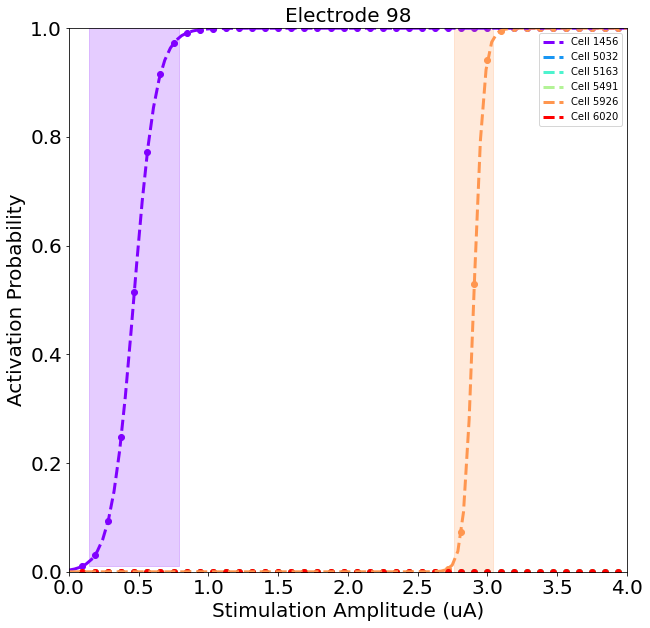

Electrode 98
Selective: True
Pure: True
Cell 1456 at 1.77 uA


In [88]:
electrode = 98
activated_cells = sig.find_activating_cells(gsort_path, electrode)
activated_cells = np.sort(activated_cells)
print(activated_cells)

selective, pure, cell, amp = evaluate_single_electrode(electrode, activated_cells, bundle_thresholds, num_std=4, selectivity_ratio=2, plot=True)
print(f"Electrode {electrode}")
print(f"Selective: {selective}")
print(f"Pure: {pure}")
print(f"Cell {cell} at {amp:.2f} uA")

In [10]:
for electrode in range(1, 50):
    activated_cells = sig.find_activating_cells(gsort_path, electrode)
    activated_cells = np.sort(activated_cells)

    selective, pure, cell, amp = evaluate_single_electrode(electrode, activated_cells, bundle_thresholds, num_std=4, selectivity_ratio=2, plot=False)
    print(f"Electrode {electrode}")
    print(f"Selective: {selective}")
    print(f"Pure: {pure}")
    print(f"Cell {cell} at {amp:.2f} uA")
    print("-------------------------")

Electrode 1
Selective: False
Pure: True
Cell 6607 at 1.97 uA
-------------------------
Electrode 2
Selective: False
Pure: False
Cell 6800 at 0.95 uA
-------------------------
Electrode 3
Selective: False
Pure: False
Cell 7066 at 1.24 uA
-------------------------
Electrode 4
Selective: False
Pure: True
Cell 50 at 2.35 uA
-------------------------
Electrode 5
Selective: True
Pure: True
Cell 6242 at 1.75 uA
-------------------------
Electrode 6
Selective: False
Pure: False
Cell 6961 at 3.65 uA
-------------------------
Electrode 7
Selective: False
Pure: True
Cell 50 at 3.48 uA
-------------------------
Electrode 8
Selective: True
Pure: True
Cell 50 at 3.09 uA
-------------------------
Electrode 9
Selective: False
Pure: True
Cell 6607 at 1.91 uA
-------------------------
Electrode 10
Selective: False
Pure: True
Cell 6991 at 1.94 uA
-------------------------
Electrode 11
Selective: False
Pure: True
Cell 6933 at -1055.99 uA
-------------------------
Electrode 12
Selective: False
Pure: True
C

In [11]:
selective_stimuli = []

for electrode in tqdm(range(1, 513)):
    activated_cells = sig.find_activating_cells(gsort_path, electrode)
    activated_cells = np.sort(activated_cells)

    selective, pure, cell, amp = evaluate_single_electrode(electrode, activated_cells, bundle_thresholds, num_std=4, selectivity_ratio=2, plot=False)
    if not np.isnan(selective) and selective:
        selective_stimuli += [electrode, cell, amp, pure]

selective_stimuli = np.array(selective_stimuli).reshape(-1, 4)

100%|██████████| 512/512 [02:05<00:00,  4.07it/s]


In [12]:
selective_stimuli = selective_stimuli[selective_stimuli[:,2] <= 3.9375]
selective_stimuli = selective_stimuli[selective_stimuli[:,2] >= 0.09375]

In [13]:
# Tell me how many unique cells are activated by selective stimuli and how many of those are in cell_ids
unique_cells = np.unique(selective_stimuli[:,1])
print(f"There are {len(unique_cells)} cells activated by selective stimuli and {len(np.intersect1d(unique_cells, cell_ids))} of those are in cell_ids")

# Tell me how unique cells can be activated by a pure selective stimuli
pure_selective_stimuli = selective_stimuli[selective_stimuli[:,3] == 1]
pure_unique_cells = np.unique(pure_selective_stimuli[:,1])
print(f"There are {len(pure_unique_cells)} cells activated by pure selective stimuli and {len(np.intersect1d(pure_unique_cells, cell_ids))} of those are in cell_ids")

There are 55 cells activated by selective stimuli and 55 of those are in cell_ids
There are 55 cells activated by pure selective stimuli and 55 of those are in cell_ids


In [14]:
np.set_printoptions(suppress=True)
print(selective_stimuli)

[[   5.         6242.            1.74646017    1.        ]
 [   8.           50.            3.09322564    1.        ]
 [  17.          301.            3.03822989    1.        ]
 [  22.         6800.            2.98465253    1.        ]
 [  26.         6607.            3.56947075    1.        ]
 [  45.         5537.            2.85010254    1.        ]
 [  48.          406.            3.22018612    1.        ]
 [  56.         6933.            1.47567964    1.        ]
 [  70.         5328.            2.45703195    1.        ]
 [  92.          812.            1.44657868    1.        ]
 [  98.         1456.            1.77328679    1.        ]
 [ 112.          557.            1.26420075    1.        ]
 [ 115.         2207.            1.95601553    1.        ]
 [ 116.          395.            3.93191956    1.        ]
 [ 119.         5328.            3.64274917    1.        ]
 [ 128.         1906.            3.61963131    1.        ]
 [ 147.         4772.            3.22157654    1.       

In [15]:
sub_bundle_selective_stimuli = selective_stimuli[bundle_thresholds[selective_stimuli[:,0].astype(int)-1] > selective_stimuli[:,2]]

In [16]:
# Tell me how many unique cells are activated by selective stimuli and how many of those are in cell_ids
unique_cells = np.unique(sub_bundle_selective_stimuli[:,1])
print(f"There are {len(unique_cells)} cells activated by sub-bundle selective stimuli and {len(np.intersect1d(unique_cells, cell_ids))} of those are in cell_ids")

# Tell me how unique cells can be activated by a pure selective stimuli
pure_sub_bundle_selective_stimuli = sub_bundle_selective_stimuli[sub_bundle_selective_stimuli[:,3] == 1]
pure_unique_cells = np.unique(pure_sub_bundle_selective_stimuli[:,1])
print(f"There are {len(pure_unique_cells)} cells activated by pure sub-bundle selective stimuli and {len(np.intersect1d(pure_unique_cells, cell_ids))} of those are in cell_ids")

There are 53 cells activated by sub-bundle selective stimuli and 53 of those are in cell_ids
There are 53 cells activated by pure sub-bundle selective stimuli and 53 of those are in cell_ids


In [17]:
print(sub_bundle_selective_stimuli)

[[   5.         6242.            1.74646017    1.        ]
 [   8.           50.            3.09322564    1.        ]
 [  17.          301.            3.03822989    1.        ]
 [  22.         6800.            2.98465253    1.        ]
 [  26.         6607.            3.56947075    1.        ]
 [  48.          406.            3.22018612    1.        ]
 [  56.         6933.            1.47567964    1.        ]
 [  70.         5328.            2.45703195    1.        ]
 [  92.          812.            1.44657868    1.        ]
 [  98.         1456.            1.77328679    1.        ]
 [ 112.          557.            1.26420075    1.        ]
 [ 115.         2207.            1.95601553    1.        ]
 [ 116.          395.            3.93191956    1.        ]
 [ 119.         5328.            3.64274917    1.        ]
 [ 128.         1906.            3.61963131    1.        ]
 [ 147.         4772.            3.22157654    1.        ]
 [ 161.         1681.            3.79832258    1.       

Save the selective stimuli with the following chunk of code:

In [22]:
temp = os.path.join(dict_path, f"selective_stimuli.npz")
print(f"Saving selective electrical stimuli to {temp}")
np.savez(temp, selective_stimuli=sub_bundle_selective_stimuli)

Saving selective electrical stimuli to /Volumes/Stream/Analysis/RETINA/2024-07-18-0/dictionary/selective_stimuli.npz


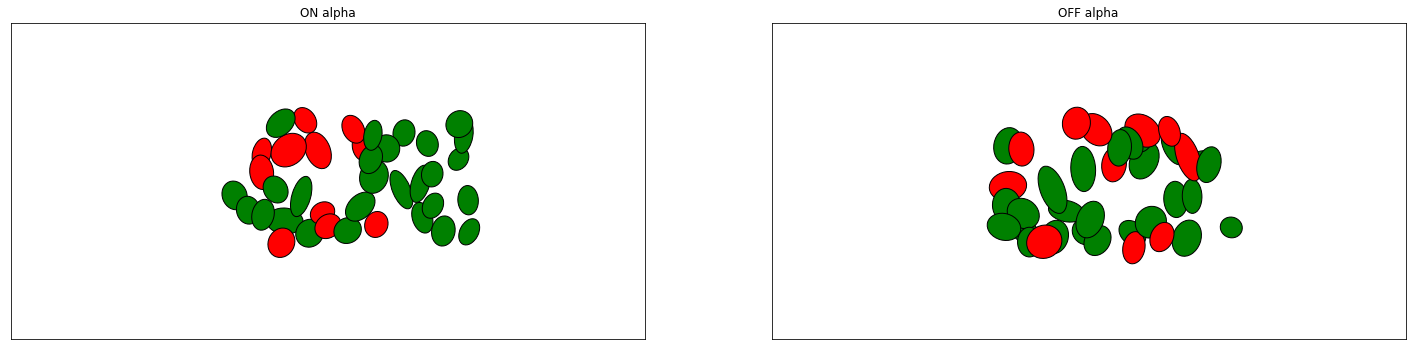

In [18]:
fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(25,10))

STIXEL = vcd.get_runtimemovie_params().pixelsPerStixelX
cell_types = ['ON alpha', 'OFF alpha']

for ax, cell_type in zip(axs, cell_types):
    for c1 in vcd.get_all_cells_similar_to_type(cell_type):
        center_x = STIXEL * vcd.get_stafit_for_cell(c1).center_x
        center_y = STIXEL * (int(vcd.get_runtimemovie_params().height) - vcd.get_stafit_for_cell(c1).center_y)
        std_x = STIXEL * vcd.get_stafit_for_cell(c1).std_x
        std_y = STIXEL * vcd.get_stafit_for_cell(c1).std_y
        rot = vcd.get_stafit_for_cell(c1).rot

        rf1 = Ellipse(xy=(center_x,center_y), width=2*std_x, height=2*std_y, angle=-rot*180/np.pi, fill=True)

        if c1 in sub_bundle_selective_stimuli[:,1]:
            rf1.set_facecolor('green')
        else:
            rf1.set_facecolor('red')
        rf1.set_edgecolor('black')
        ax.add_patch(rf1)

    ax.set_xlim(0, 640-1)
    ax.set_ylim(0, 320-1)
    ax.set_aspect('equal')
    ax.set_title(cell_type)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)

plt.show()

In [ ]:
for cell_id in [7051]:

    # Extract EI for desired cell
    cell_ei = vcd.get_ei_for_cell(cell_id).ei

    # Find negative peak for each recording electrode
    ei = np.amin(cell_ei,axis=1)
    thresh = -1
    good_inds = np.argwhere(ei < thresh).flatten()
    channel_noise = vcd.channel_noise

    # Assign compartments
    soma_inds = []
    axon_inds = []
    mixed_inds = []
    dendrite_inds = []
    for elec in good_inds:
        if eil.axonorsomaRatio(cell_ei[elec,:]) == 'soma':
            soma_inds.append(elec)
        elif eil.axonorsomaRatio(cell_ei[elec,:]) == 'axon':
            axon_inds.append(elec)
        elif eil.axonorsomaRatio(cell_ei[elec,:]) == 'dendrite':
            dendrite_inds.append(elec)
        elif eil.axonorsomaRatio(cell_ei[elec,:]) == 'mixed':
            mixed_inds.append(elec)

    fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(15,15))

    # Plot electrodes
    coords = vcd.get_electrode_map()
    ax.scatter(coords[:,0], coords[:,1], facecolors='none', edgecolors='k', s=20)

    # Plot EI
    ei_size_factor = -100
    ax.scatter(coords[soma_inds,0], coords[soma_inds,1], facecolors=eil.corrColDict['soma'], 
            edgecolors='none', s=ei[soma_inds]*ei_size_factor, alpha=0.8)
    ax.scatter(coords[axon_inds,0], coords[axon_inds,1], facecolors=eil.corrColDict['axon'], 
            edgecolors='none', s=ei[axon_inds]*ei_size_factor, alpha=0.8)
    ax.scatter(coords[mixed_inds,0], coords[mixed_inds,1], facecolors=eil.corrColDict['mixed'], 
            edgecolors='none', s=ei[mixed_inds]*ei_size_factor, alpha=0.8)
    ax.scatter(coords[dendrite_inds,0], coords[dendrite_inds,1], facecolors=eil.corrColDict['dendrite'], 
            edgecolors='none', s=ei[dendrite_inds]*ei_size_factor, alpha=0.8)

    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
    # ax.set_xlim([min(coords[good_inds,0])-100, max(coords[good_inds,0])+100])
    # ax.set_ylim([min(coords[good_inds,1])-100, max(coords[good_inds,1])+100])
    ax.axes.set_aspect('equal')


    legend_elements = [Line2D([0], [0], marker='o', color='w', label='Soma',
                    markerfacecolor=eil.corrColDict['soma'], markersize=15),
                    Line2D([0], [0], marker='o', color='w', label='Axon',
                    markerfacecolor=eil.corrColDict['axon'], markersize=15),
                    Line2D([0], [0], marker='o', color='w', label='Mixed',
                    markerfacecolor=eil.corrColDict['mixed'], markersize=15),
                    Line2D([0], [0], marker='o', color='w', label='Dendrite',
                    markerfacecolor=eil.corrColDict['dendrite'], markersize=15)]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=20)

    # Identify from selective_stimuli which electrodes are selective for cell_id, and get the corresponding amp
    selective_subset = selective_stimuli[selective_stimuli[:,1] == cell_id]
    selective_electrodes = selective_subset[:,0].astype(int)
    selective_amps = selective_subset[:,2]

    # Label electrodes
    for z,elec in enumerate(selective_electrodes):
        num = f"{selective_amps[z]:.2f}"
        plt.annotate(num, (coords[elec-1,0],coords[elec-1,1]), textcoords='offset points', xytext=(0,12), ha='center', fontsize=10)

    plt.show()

In [ ]:
for cell_id in [7051]:

    # Extract EI for desired cell
    cell_ei = vcd.get_ei_for_cell(cell_id).ei

    # Find negative peak for each recording electrode
    ei = np.amin(cell_ei,axis=1)
    thresh = -1
    good_inds = np.argwhere(ei < thresh).flatten()
    channel_noise = vcd.channel_noise

    # Assign compartments
    soma_inds = []
    axon_inds = []
    mixed_inds = []
    dendrite_inds = []
    for elec in good_inds:
        if eil.axonorsomaRatio(cell_ei[elec,:]) == 'soma':
            soma_inds.append(elec)
        elif eil.axonorsomaRatio(cell_ei[elec,:]) == 'axon':
            axon_inds.append(elec)
        elif eil.axonorsomaRatio(cell_ei[elec,:]) == 'dendrite':
            dendrite_inds.append(elec)
        elif eil.axonorsomaRatio(cell_ei[elec,:]) == 'mixed':
            mixed_inds.append(elec)

    fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(15,15))

    # Plot electrodes
    coords = vcd.get_electrode_map()
    ax.scatter(coords[:,0], coords[:,1], facecolors='none', edgecolors='k', s=20)

    # Plot EI
    ei_size_factor = -100
    ax.scatter(coords[soma_inds,0], coords[soma_inds,1], facecolors=eil.corrColDict['soma'], 
            edgecolors='none', s=ei[soma_inds]*ei_size_factor, alpha=0.8)
    ax.scatter(coords[axon_inds,0], coords[axon_inds,1], facecolors=eil.corrColDict['axon'], 
            edgecolors='none', s=ei[axon_inds]*ei_size_factor, alpha=0.8)
    ax.scatter(coords[mixed_inds,0], coords[mixed_inds,1], facecolors=eil.corrColDict['mixed'], 
            edgecolors='none', s=ei[mixed_inds]*ei_size_factor, alpha=0.8)
    ax.scatter(coords[dendrite_inds,0], coords[dendrite_inds,1], facecolors=eil.corrColDict['dendrite'], 
            edgecolors='none', s=ei[dendrite_inds]*ei_size_factor, alpha=0.8)

    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
    # ax.set_xlim([min(coords[good_inds,0])-100, max(coords[good_inds,0])+100])
    # ax.set_ylim([min(coords[good_inds,1])-100, max(coords[good_inds,1])+100])
    ax.axes.set_aspect('equal')


    legend_elements = [Line2D([0], [0], marker='o', color='w', label='Soma',
                    markerfacecolor=eil.corrColDict['soma'], markersize=15),
                    Line2D([0], [0], marker='o', color='w', label='Axon',
                    markerfacecolor=eil.corrColDict['axon'], markersize=15),
                    Line2D([0], [0], marker='o', color='w', label='Mixed',
                    markerfacecolor=eil.corrColDict['mixed'], markersize=15),
                    Line2D([0], [0], marker='o', color='w', label='Dendrite',
                    markerfacecolor=eil.corrColDict['dendrite'], markersize=15)]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=20)

    # Label electrodes
    for elec in np.arange(1,513):
        try:
            amps, probs, slp, thr, std, success = sig.compute_sigmoid(gsort_path, pickle_path_base, cell_id, f"p{elec}", plot=False)
            if np.isnan(thr):
                continue
            if success:
                num = f"{thr:.2f}"
                plt.annotate(num, (coords[elec-1,0],coords[elec-1,1]), textcoords='offset points', xytext=(0,12), ha='center', fontsize=10)
        except:
            continue

    plt.show()

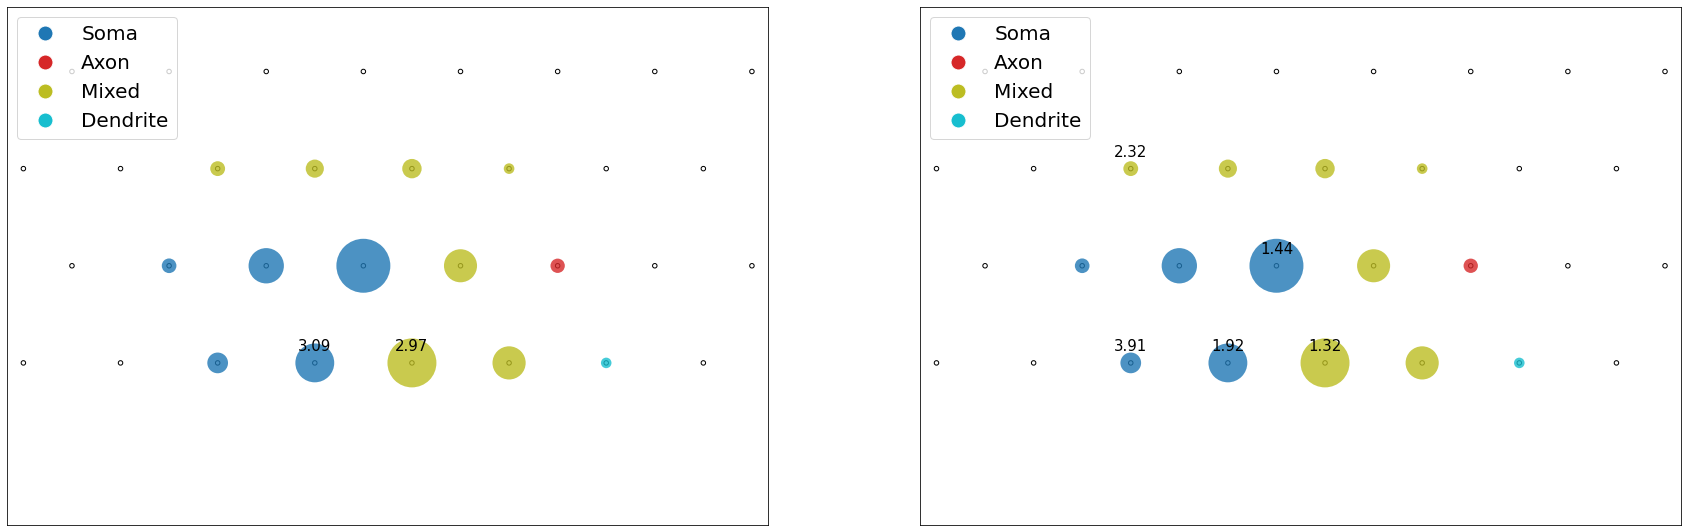

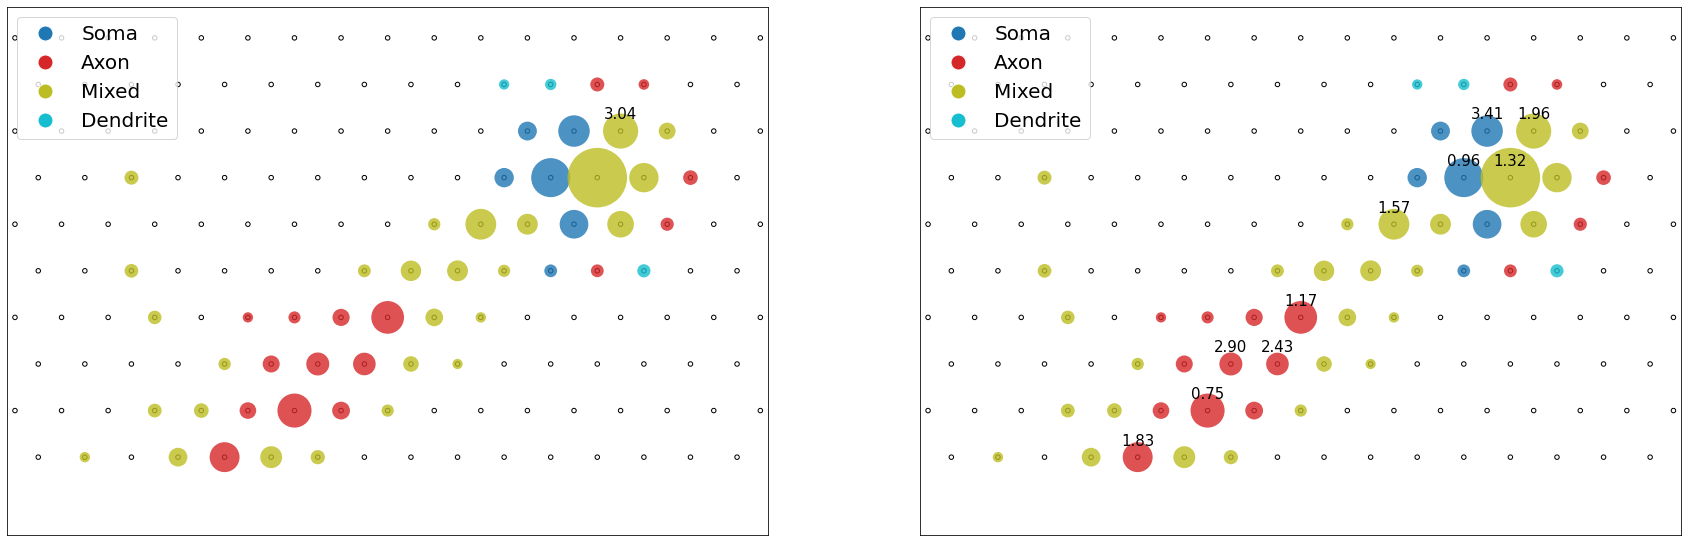

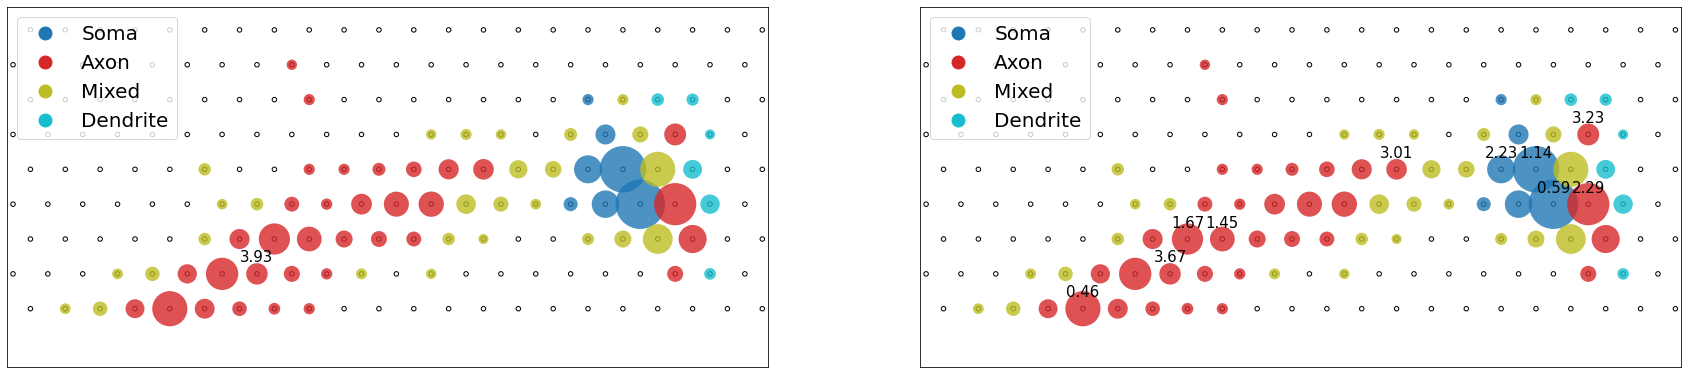

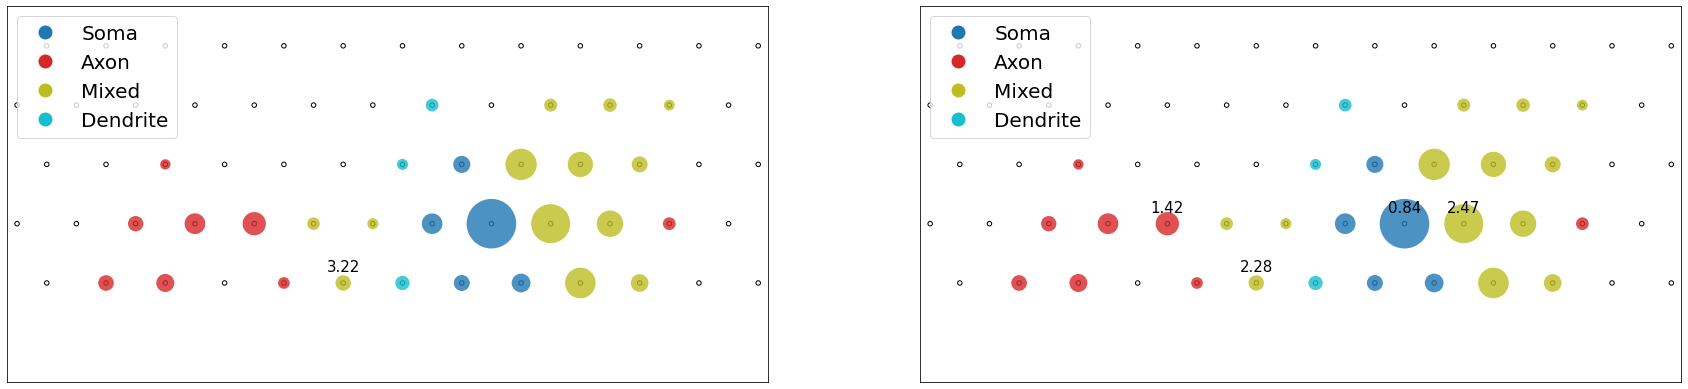

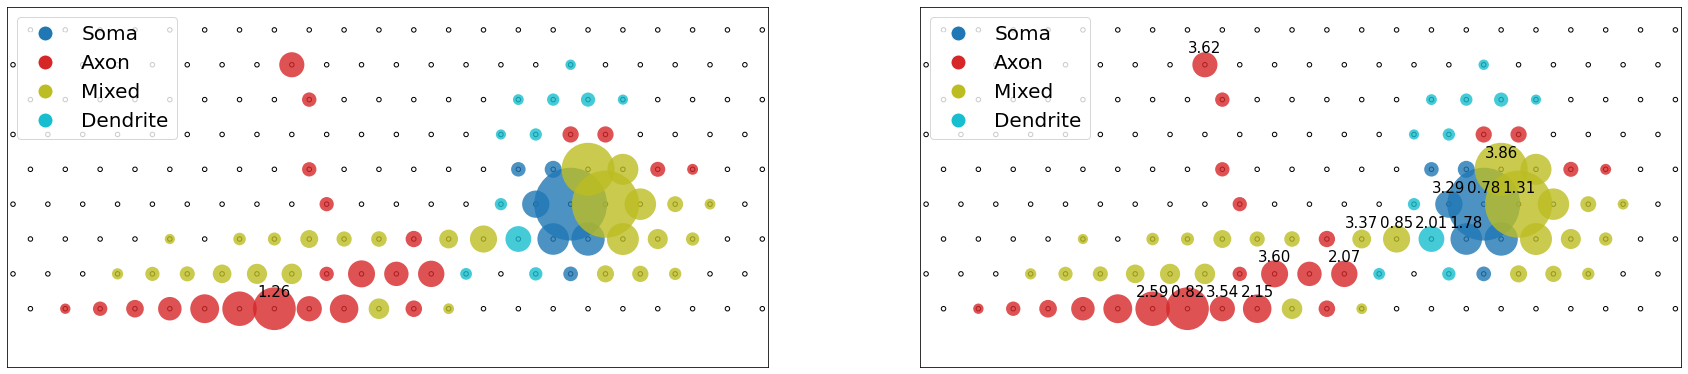

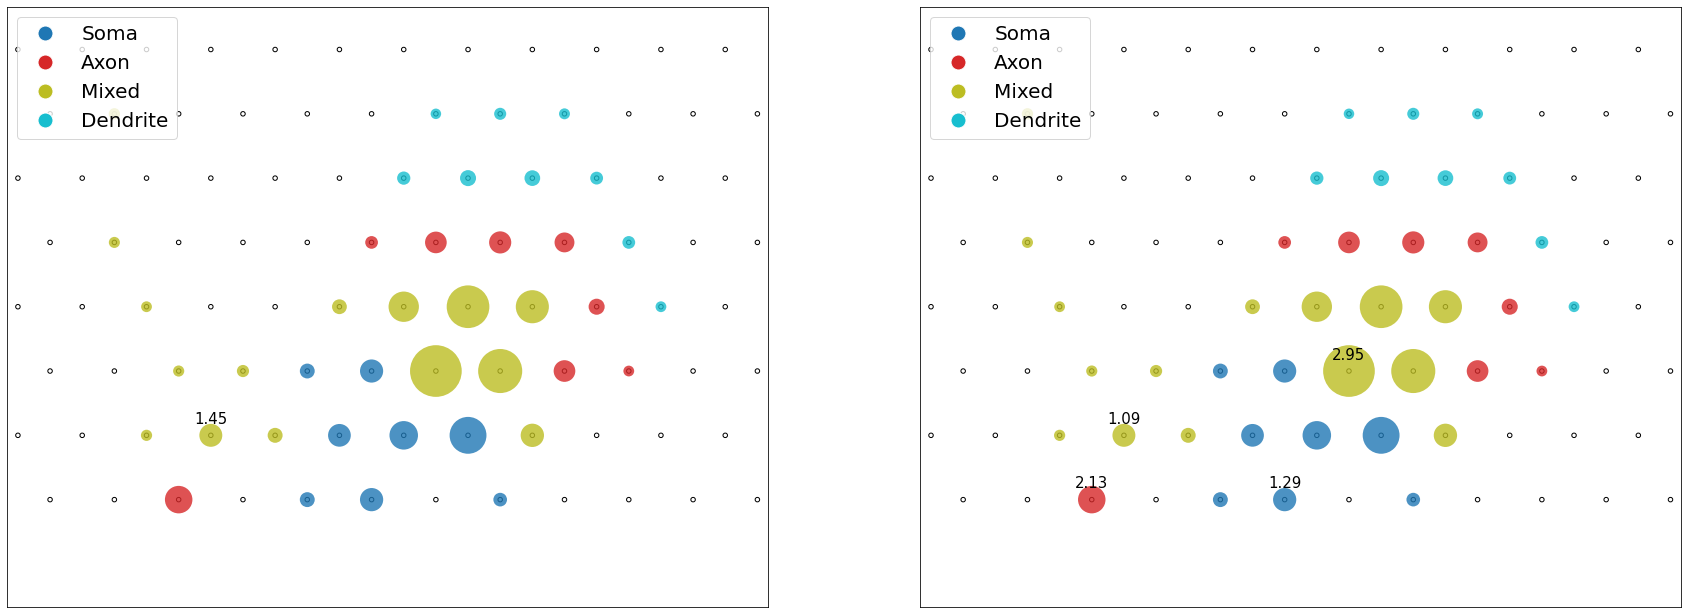

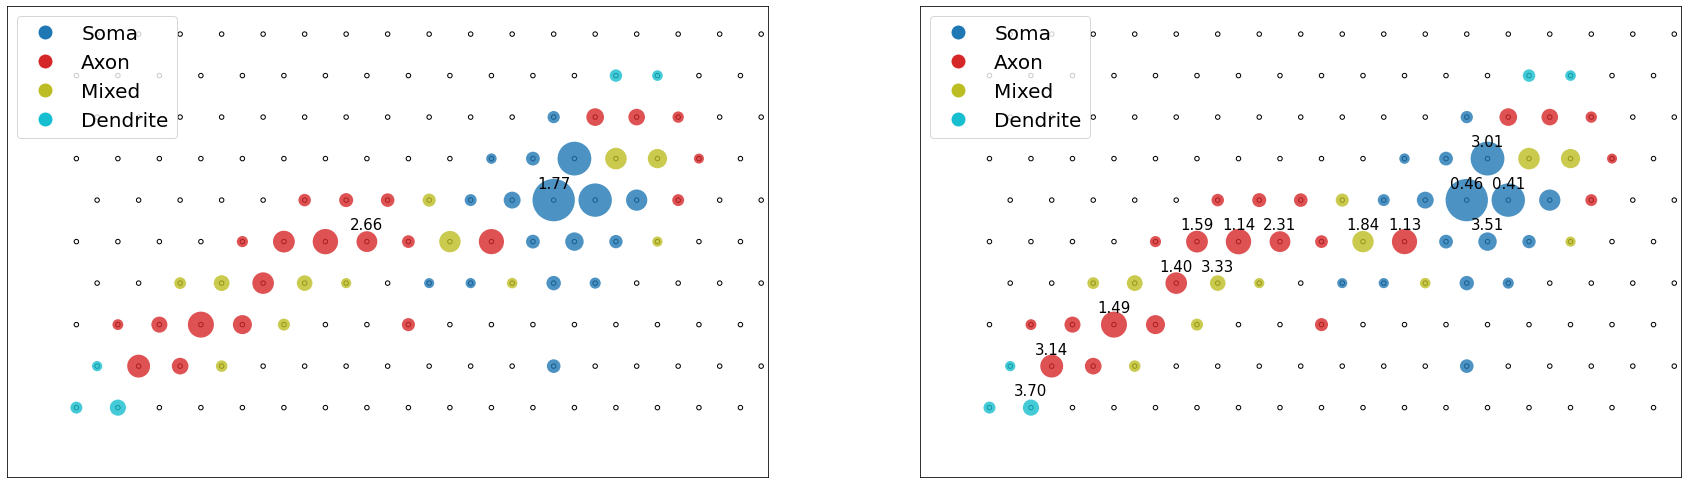

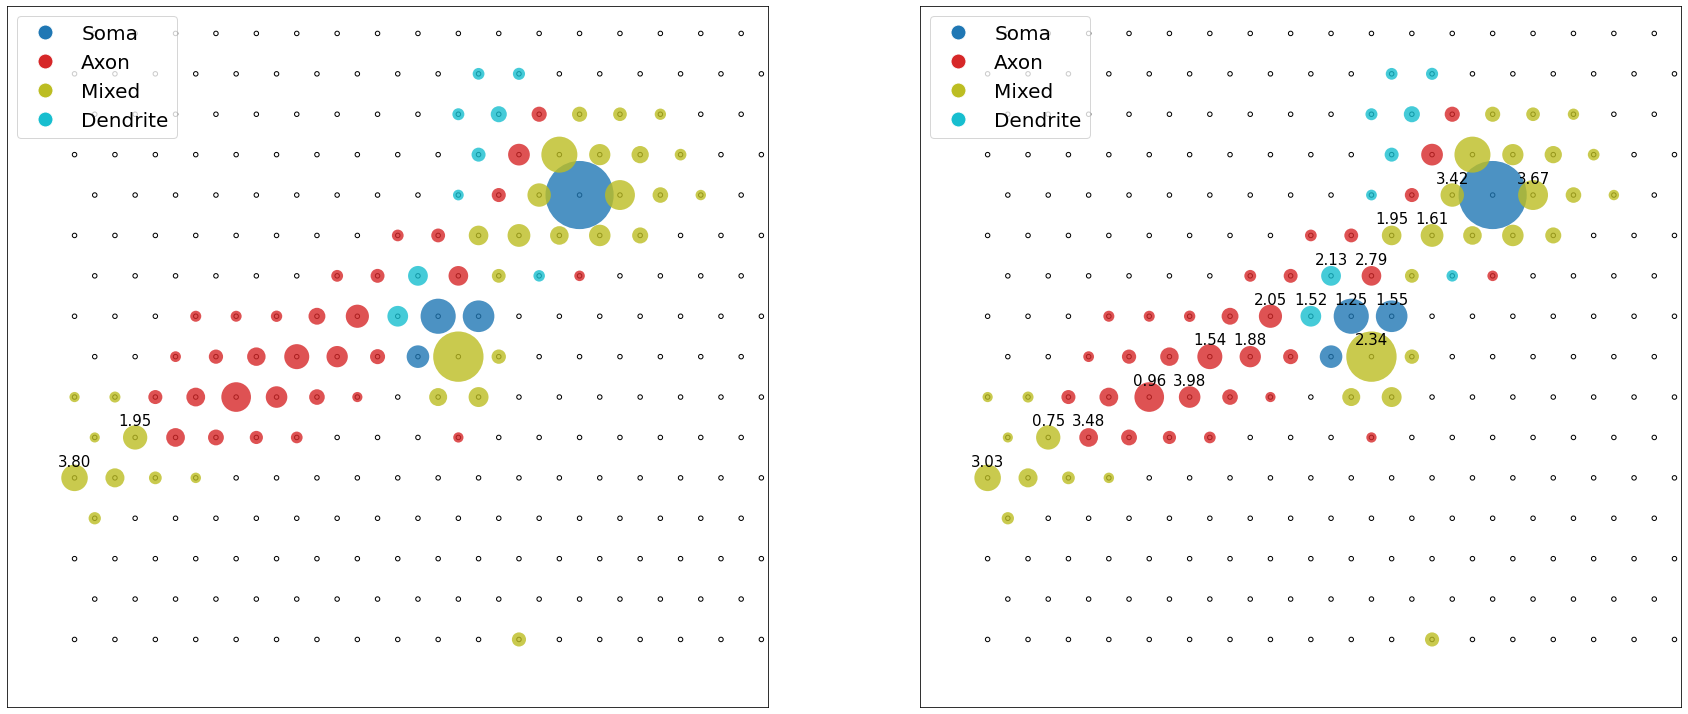

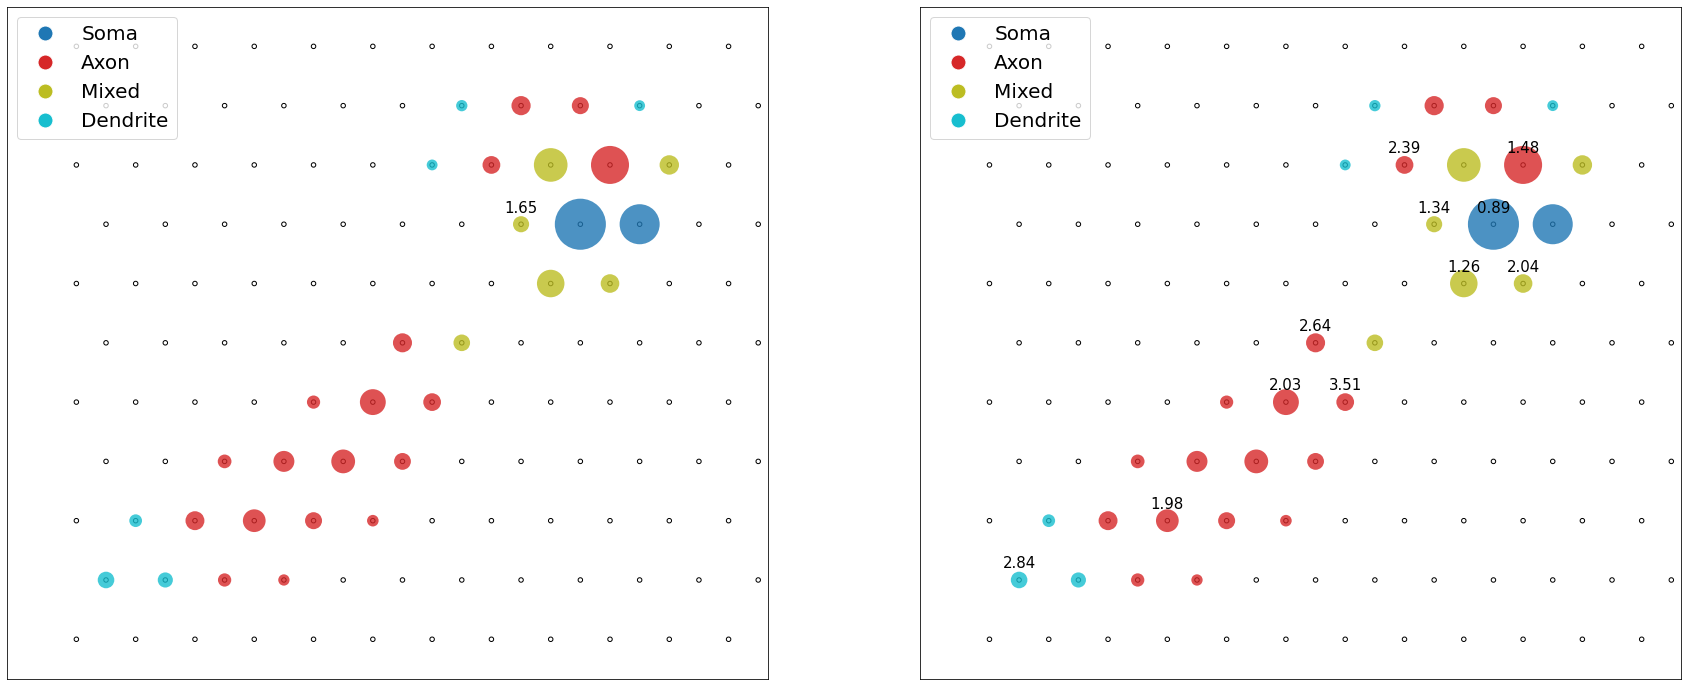

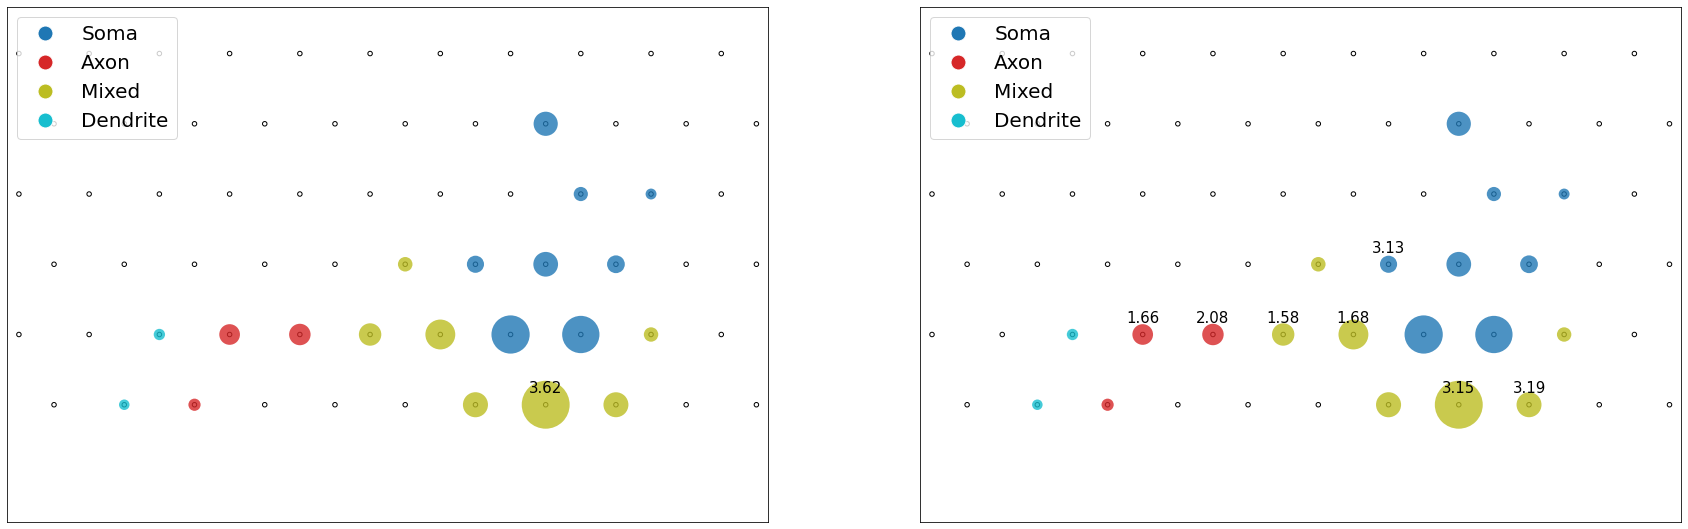

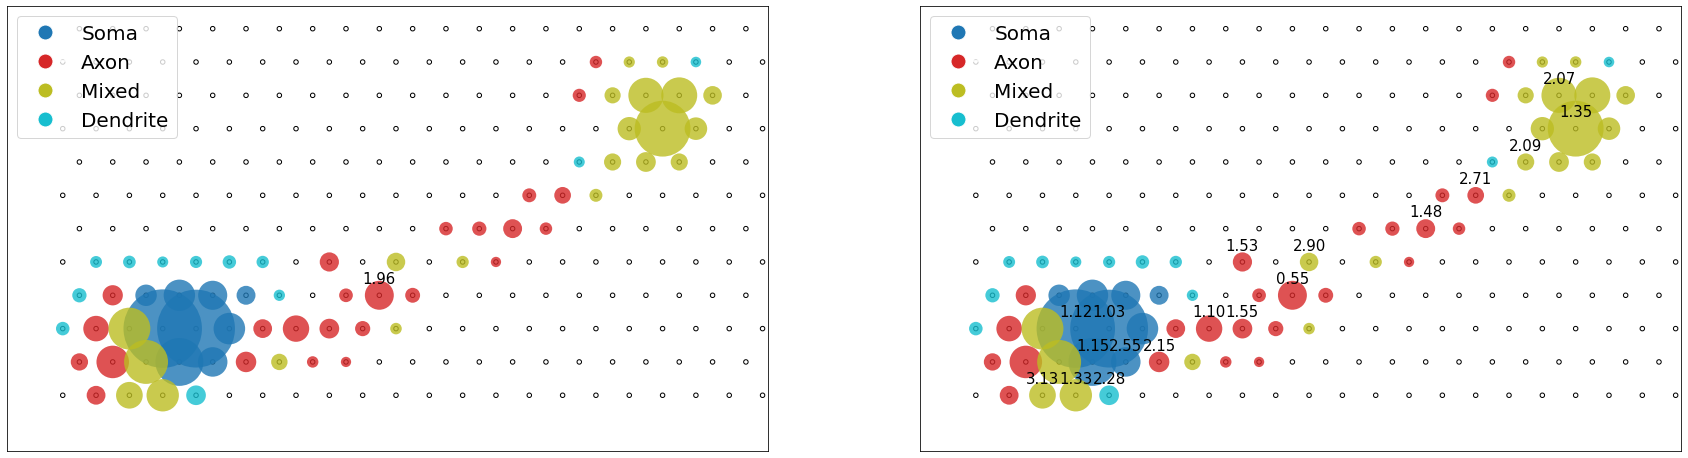

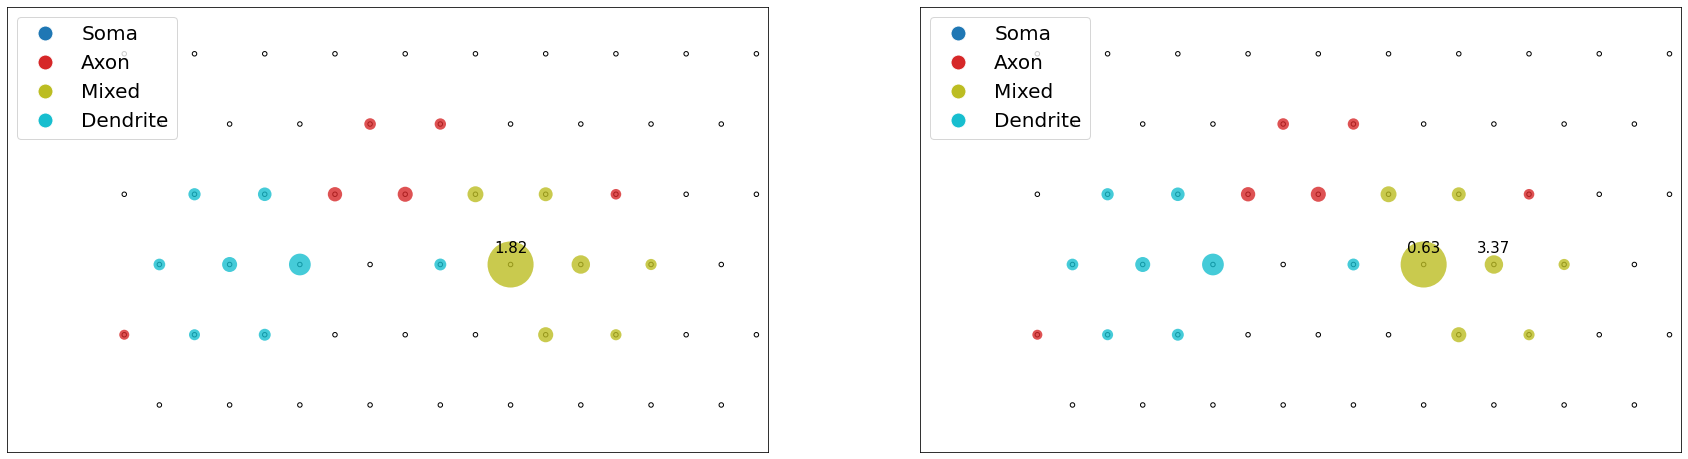

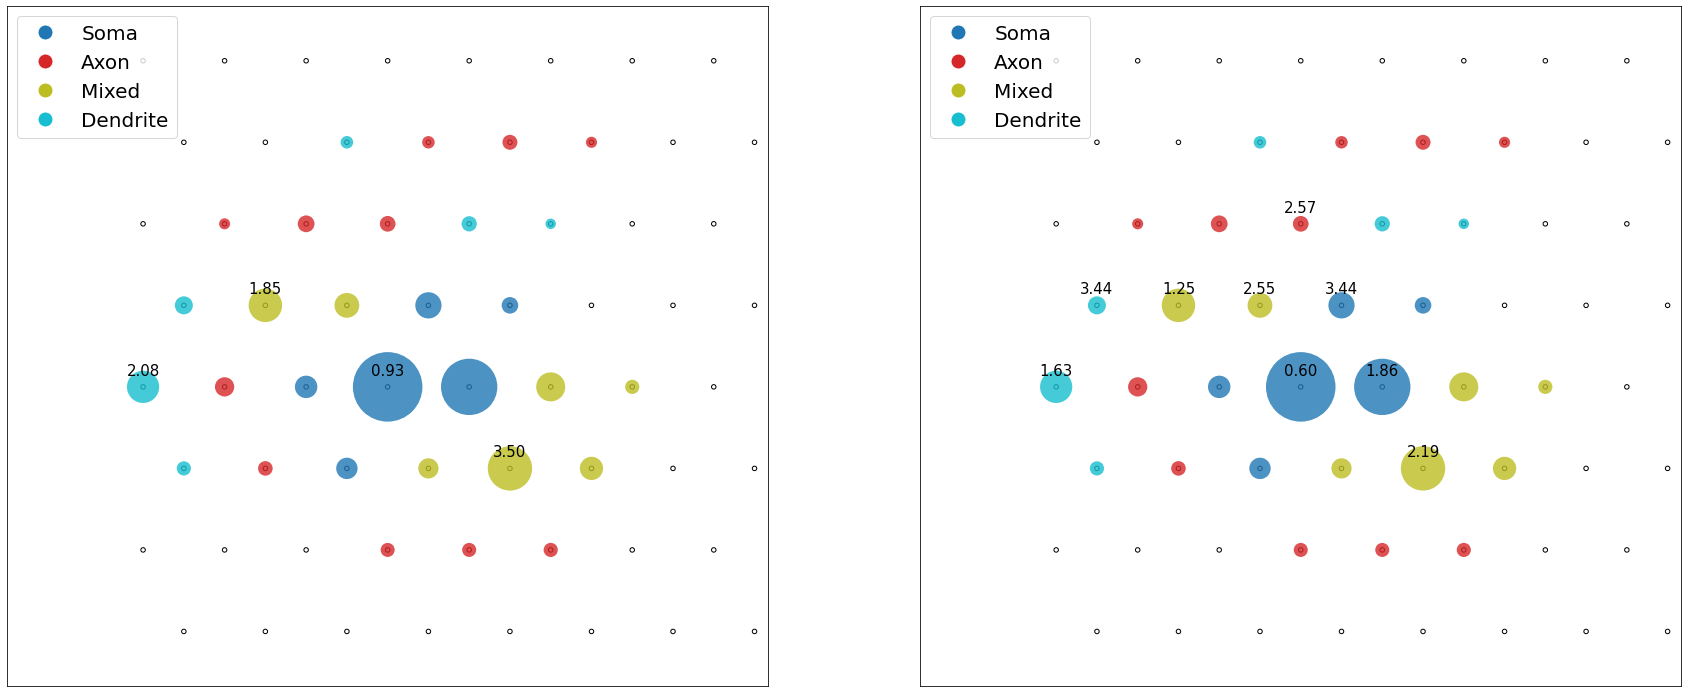

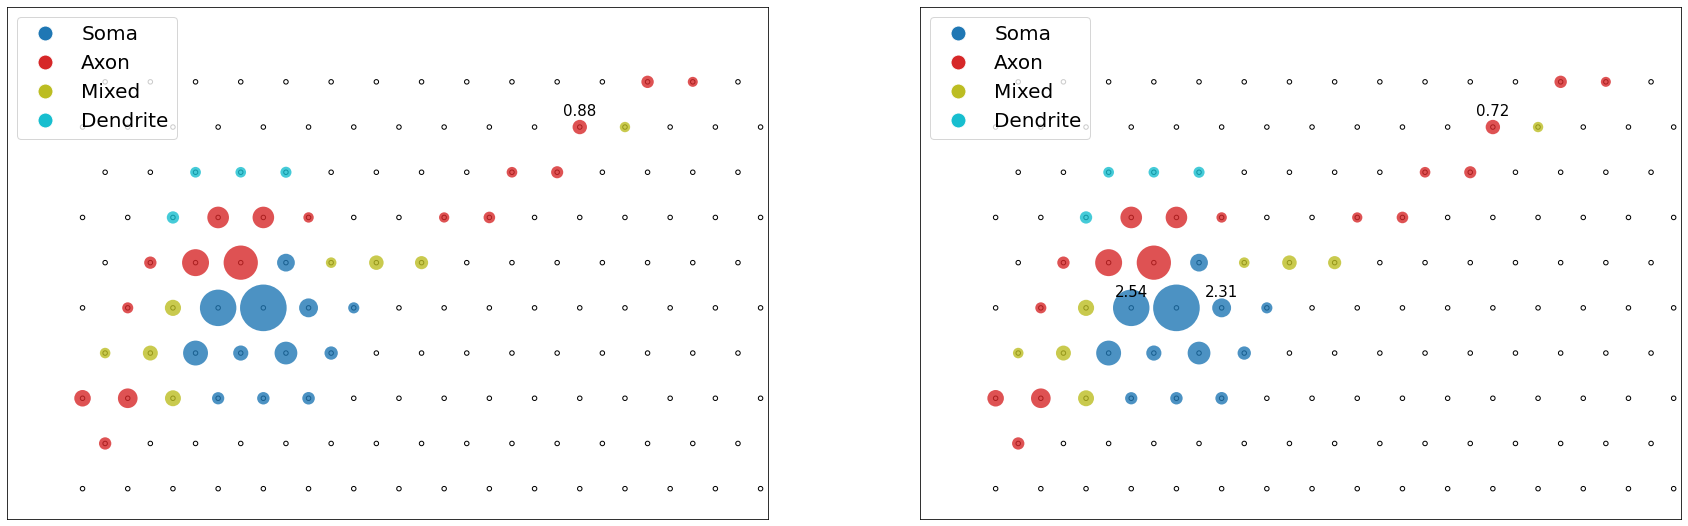

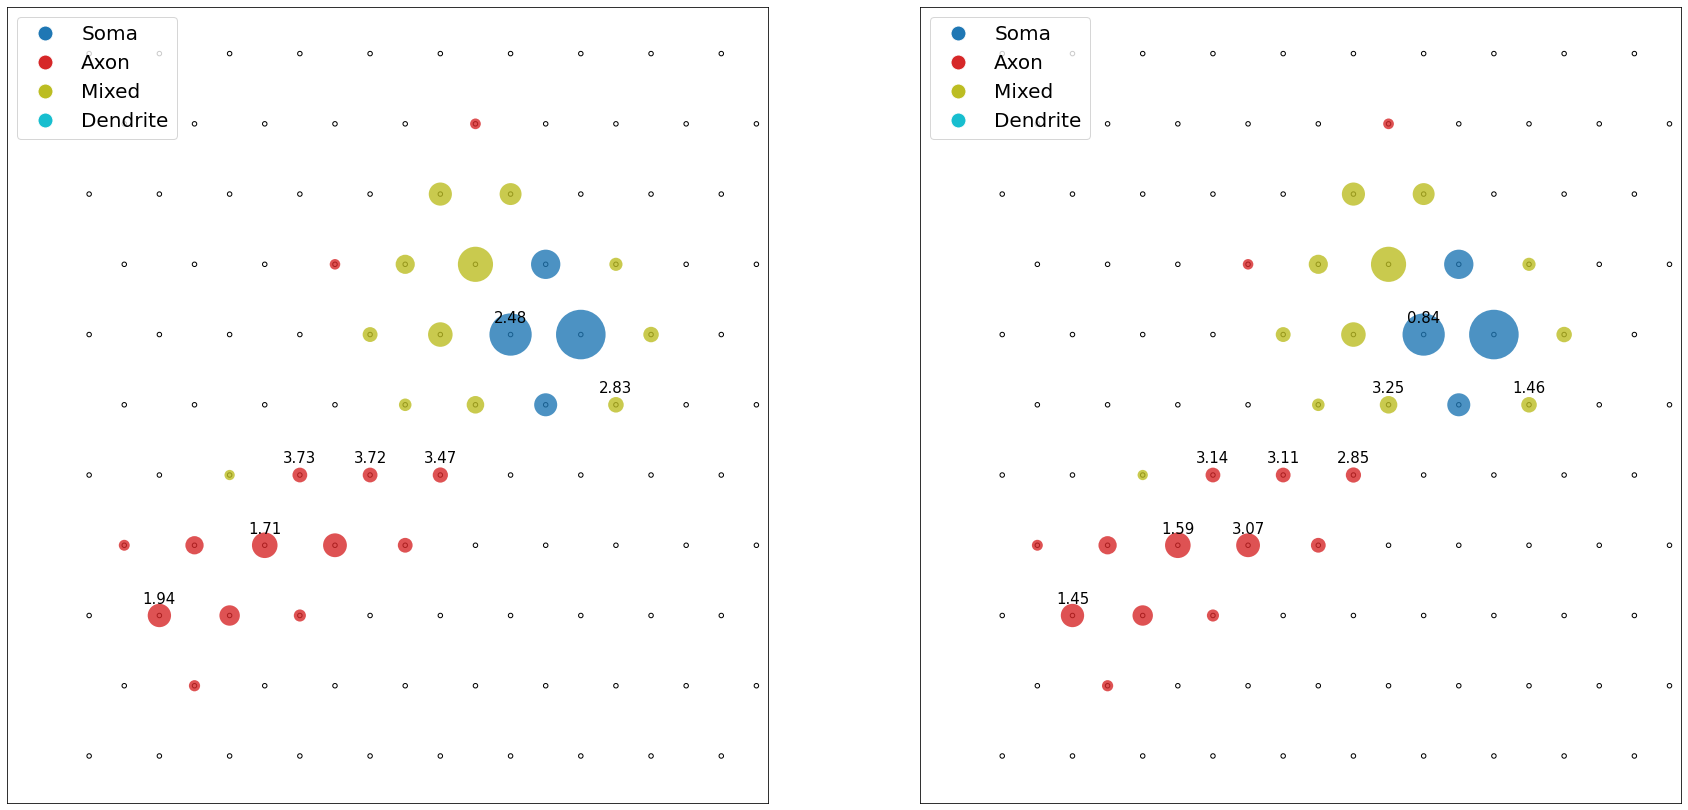

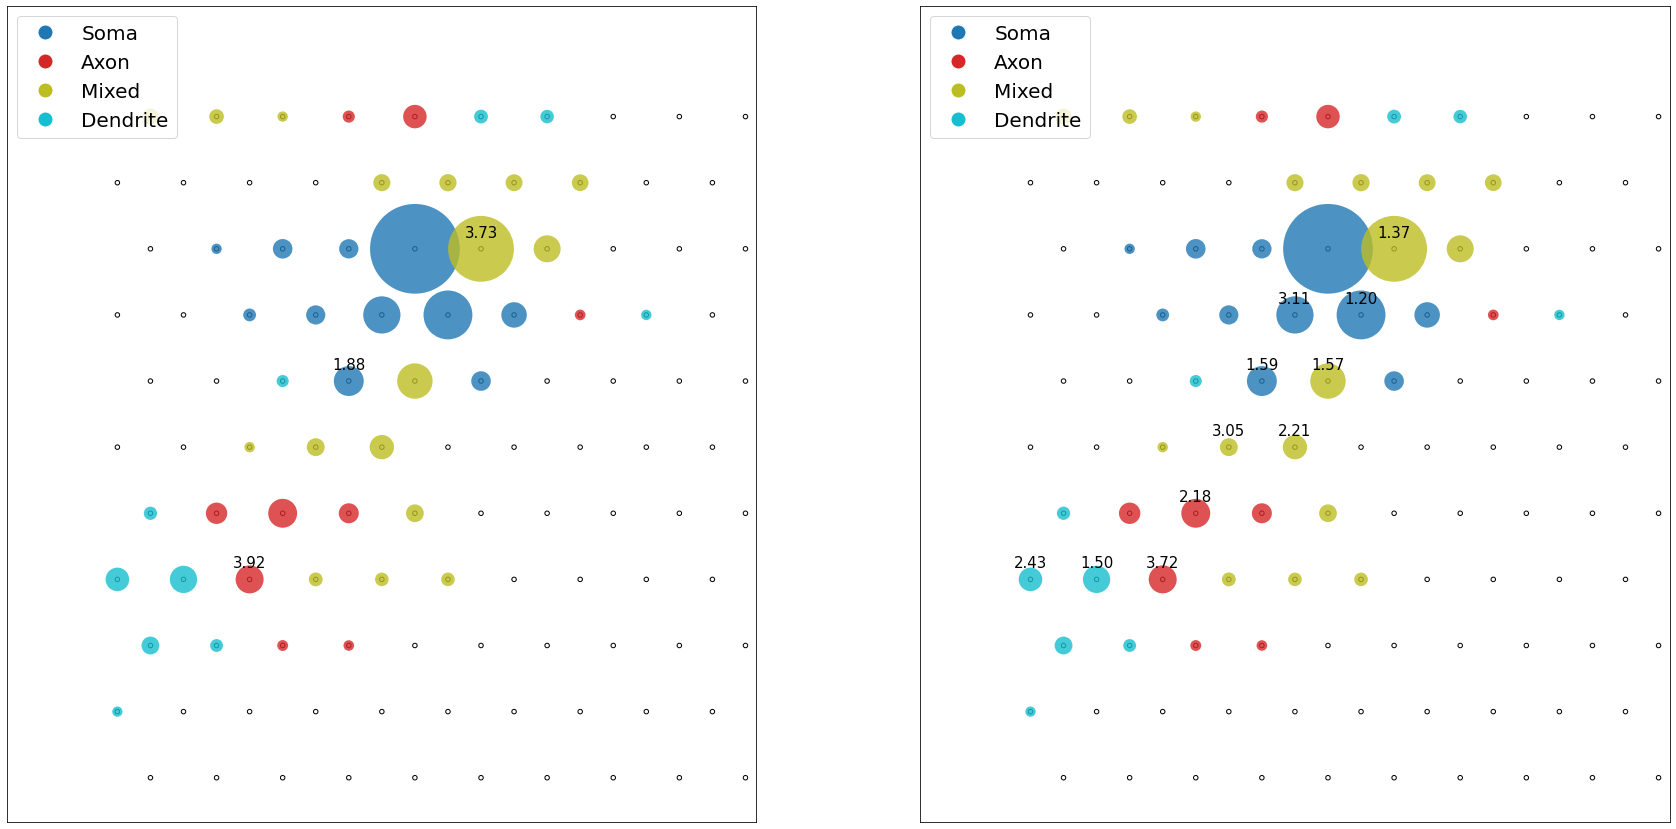

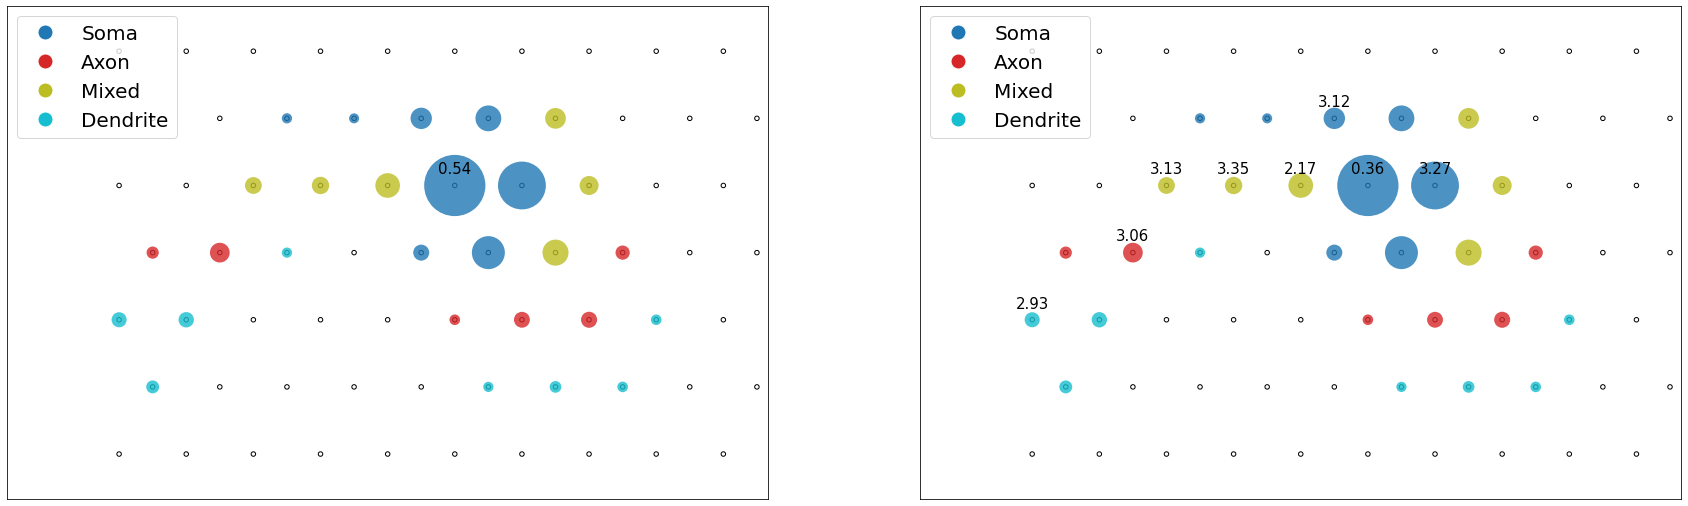

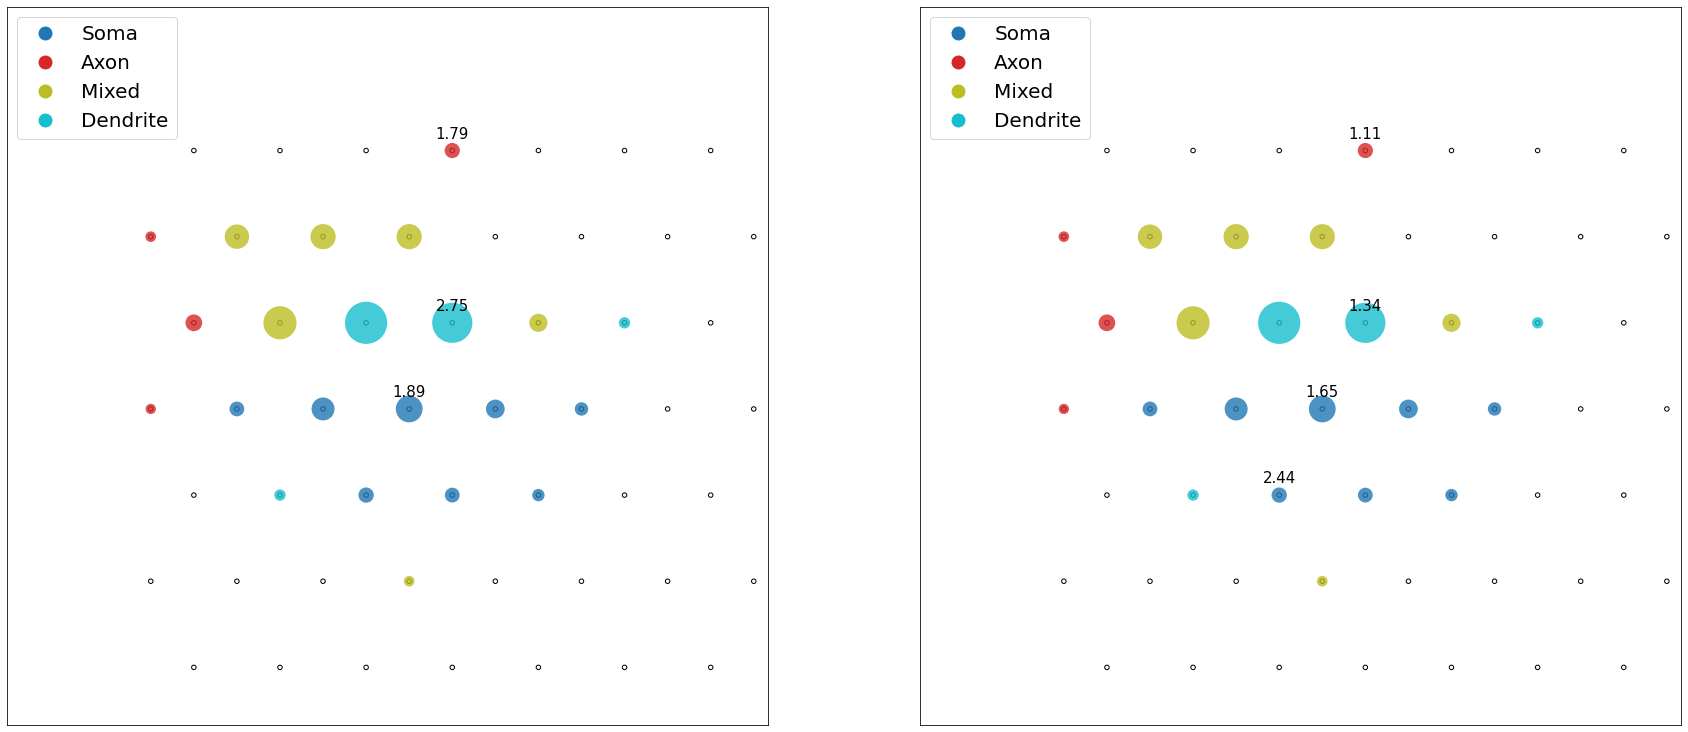

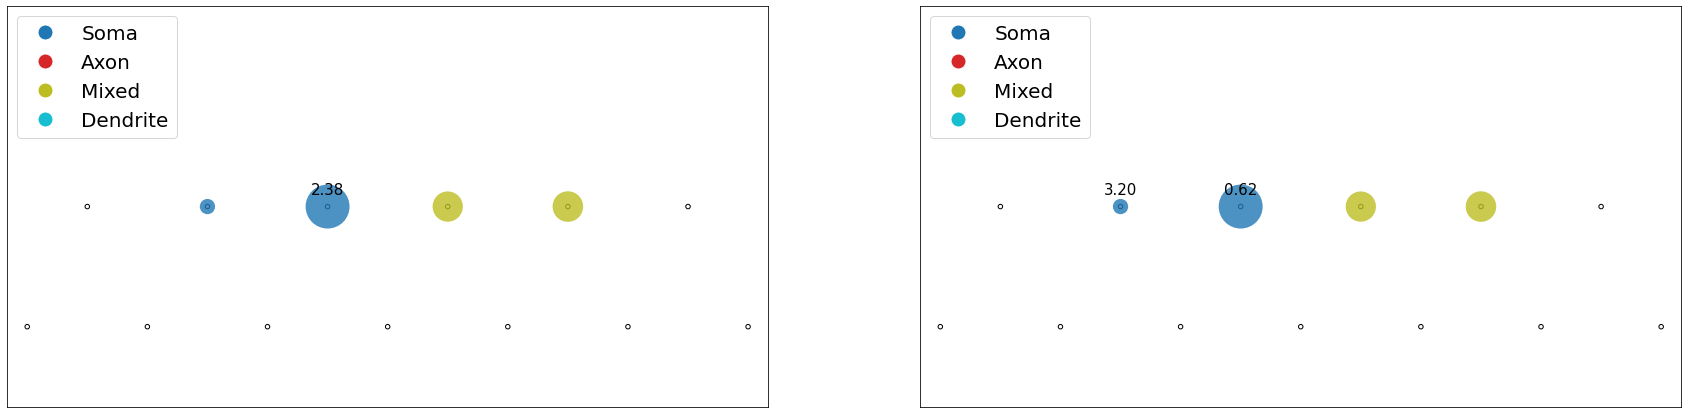

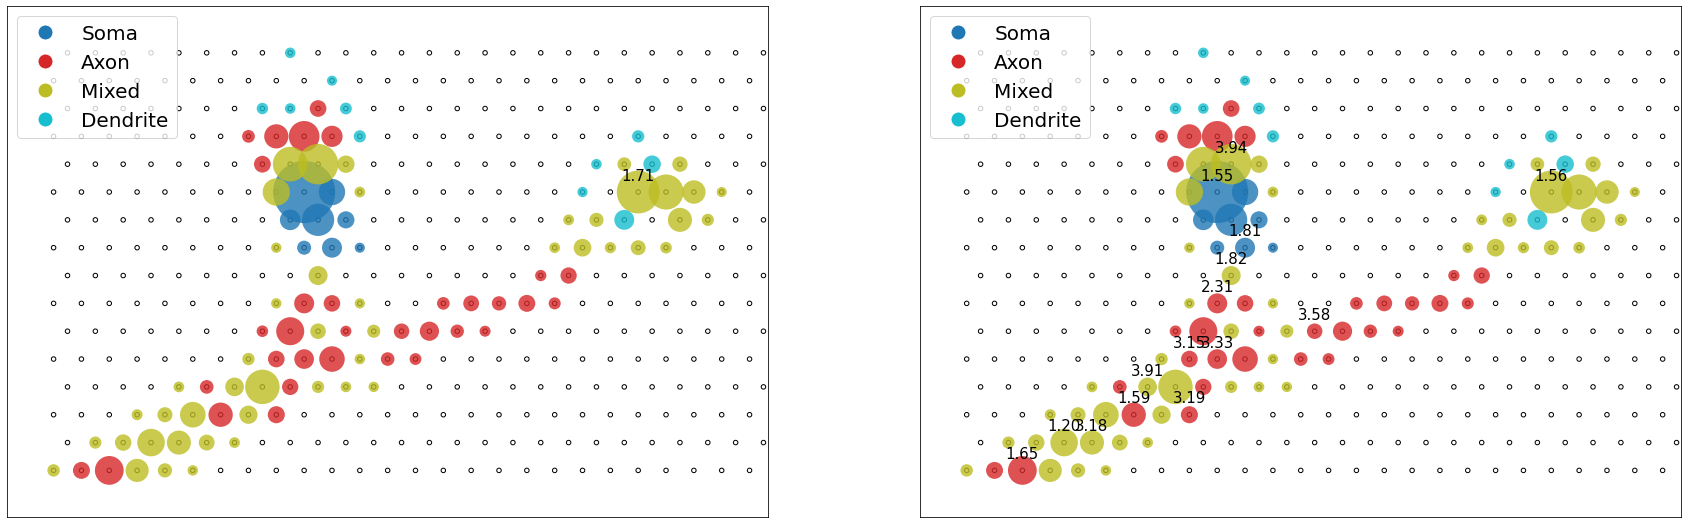

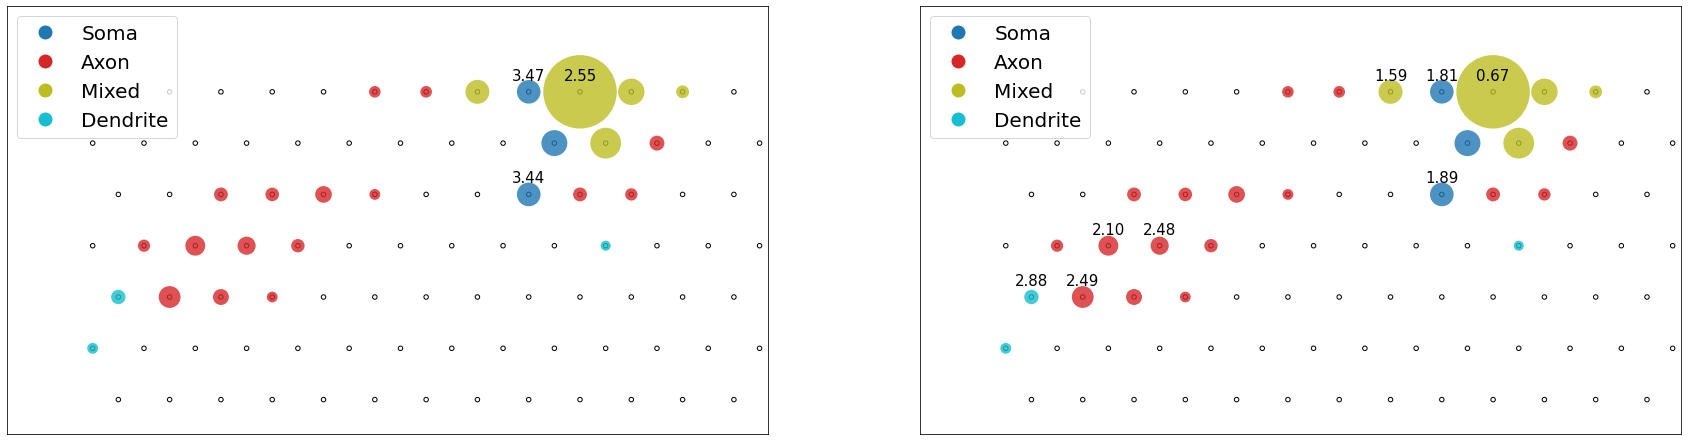

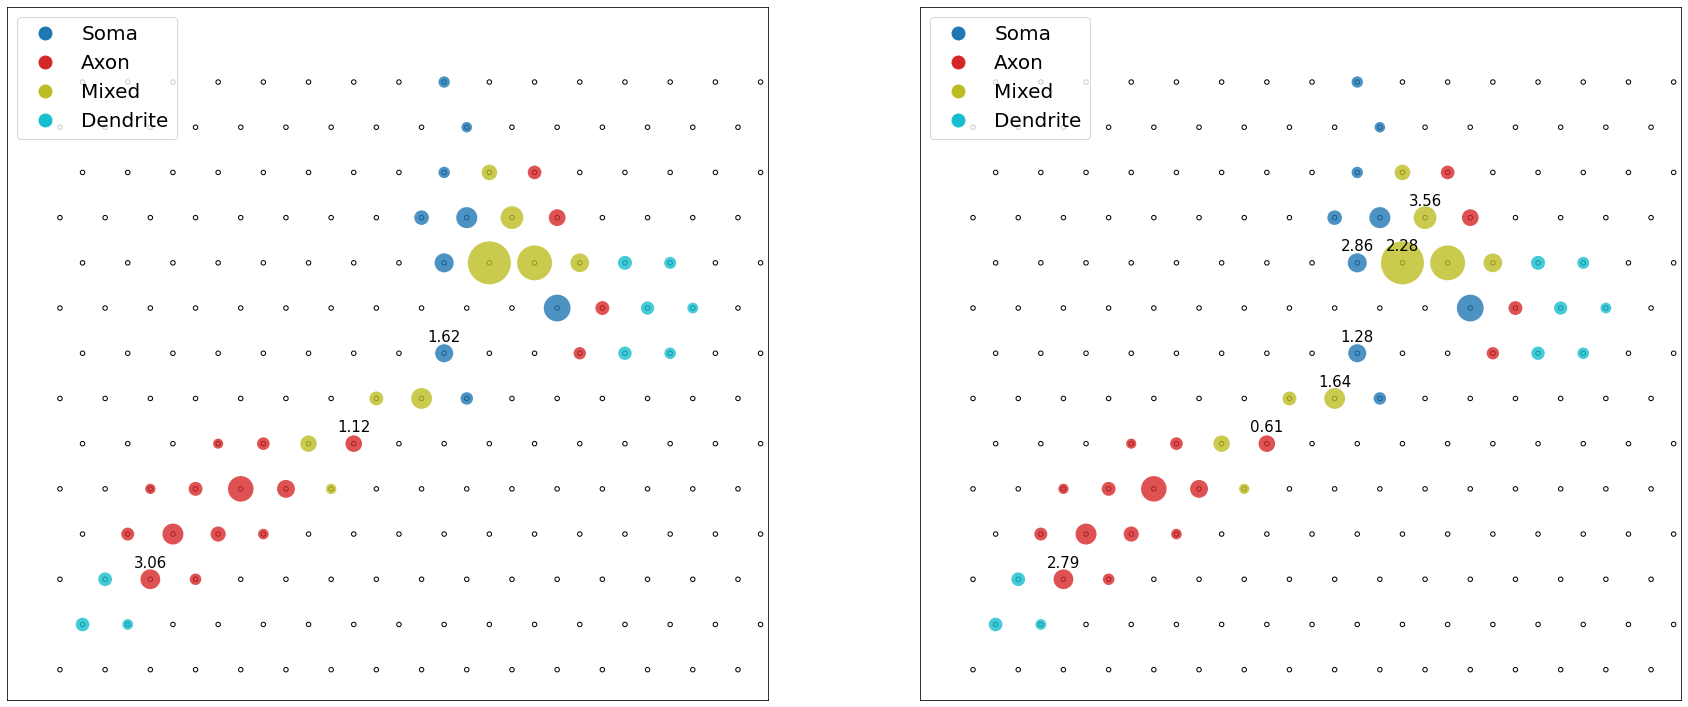

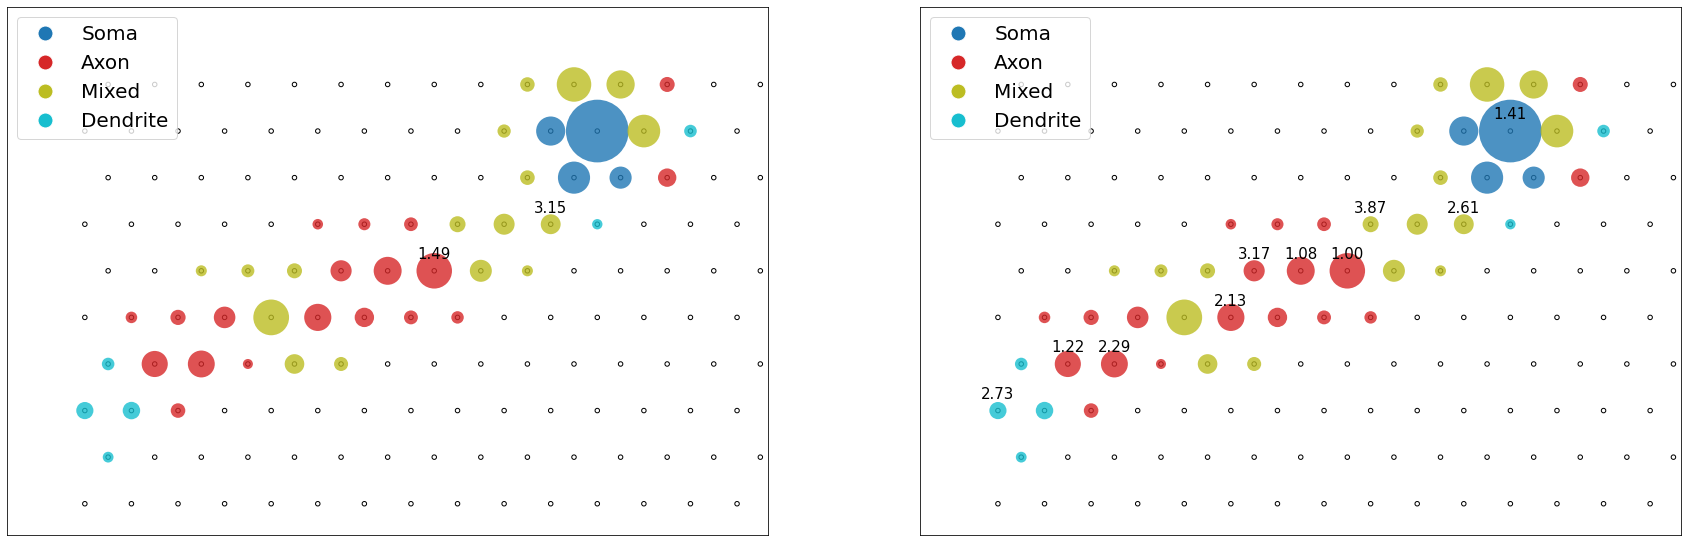

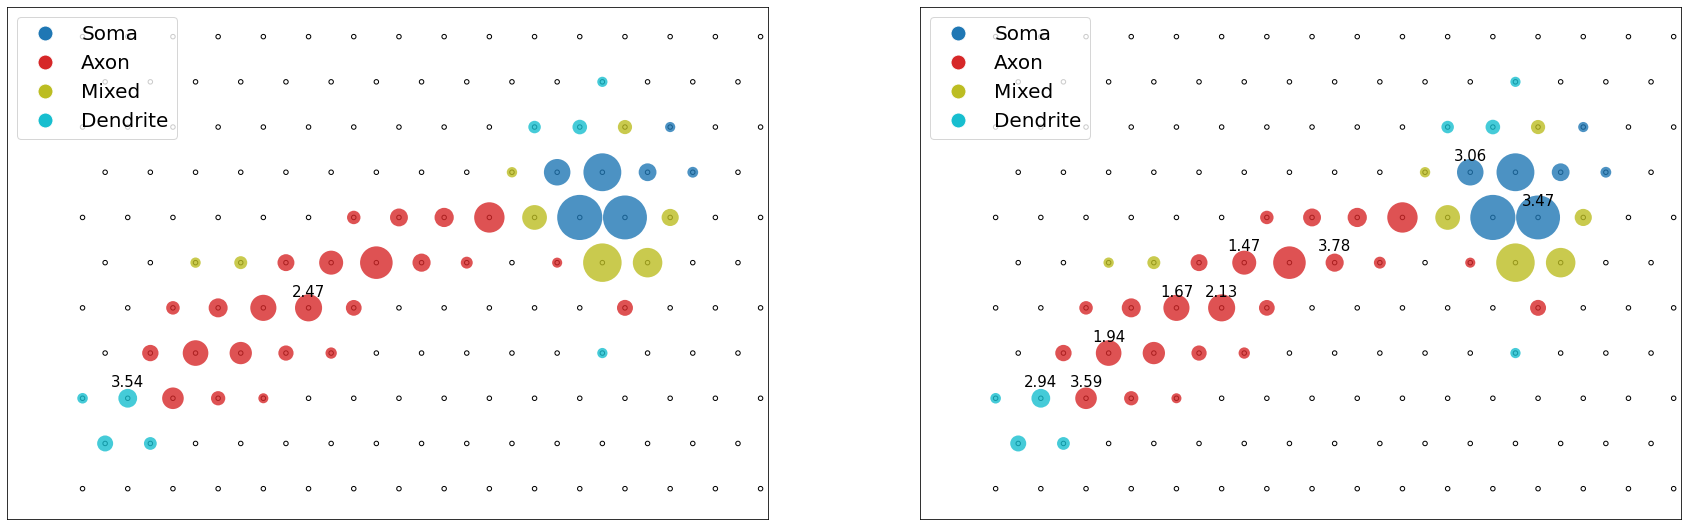

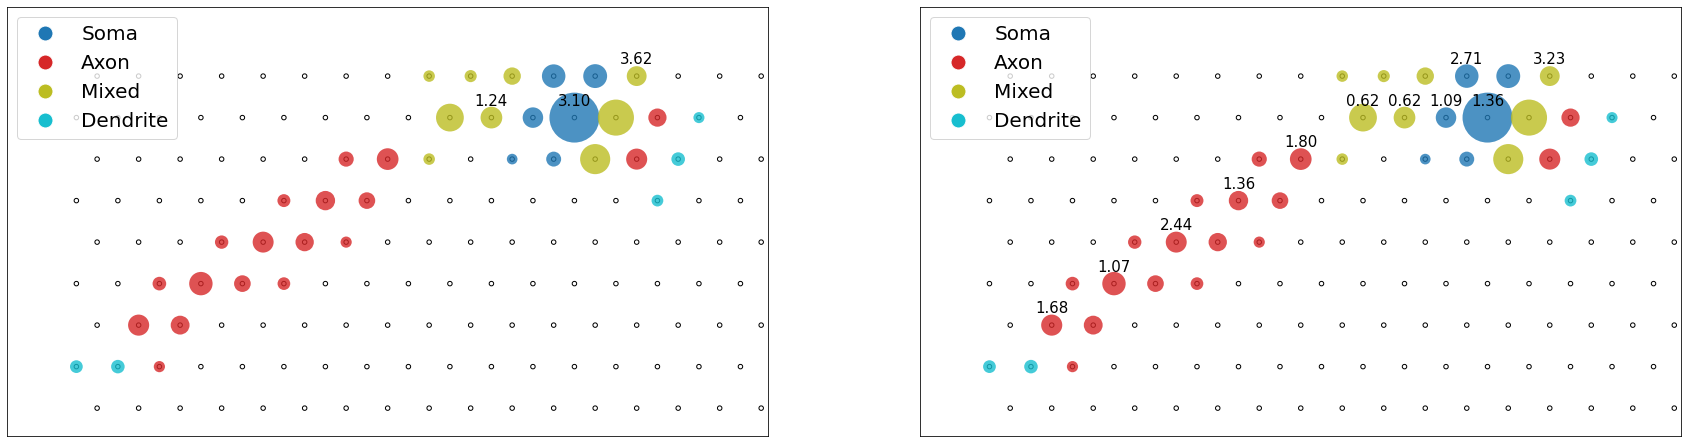

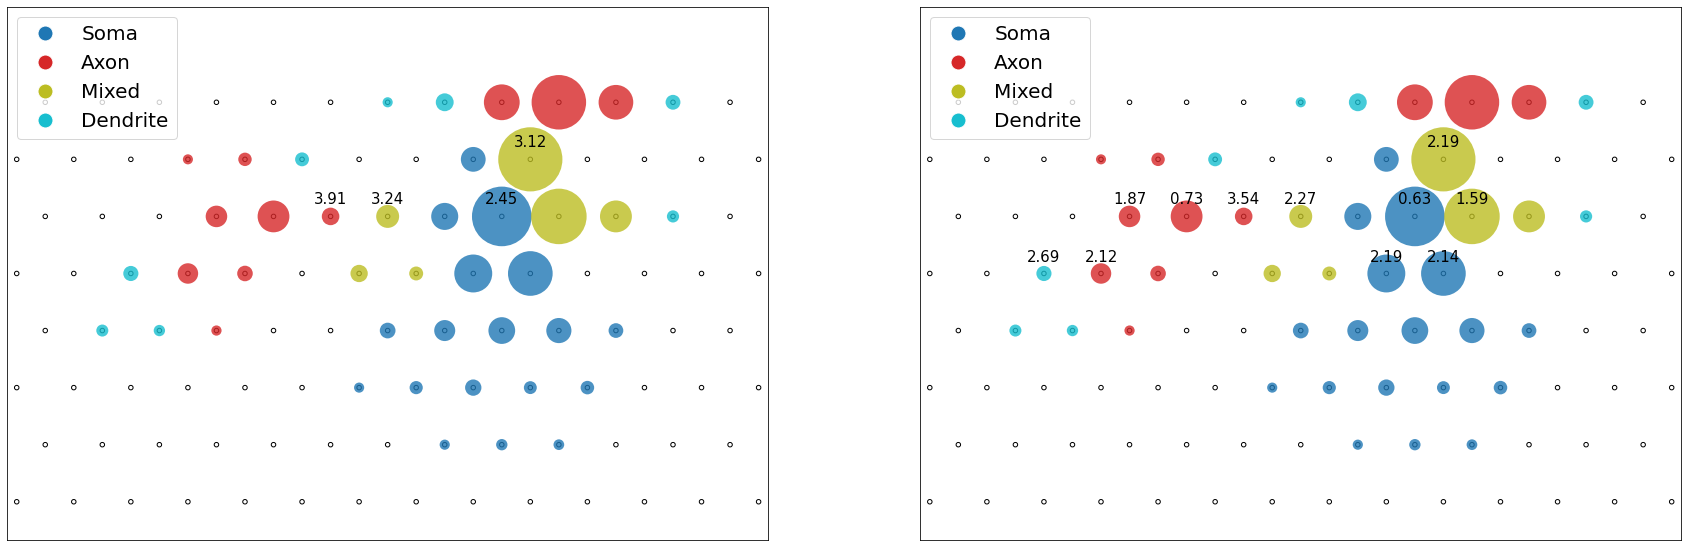

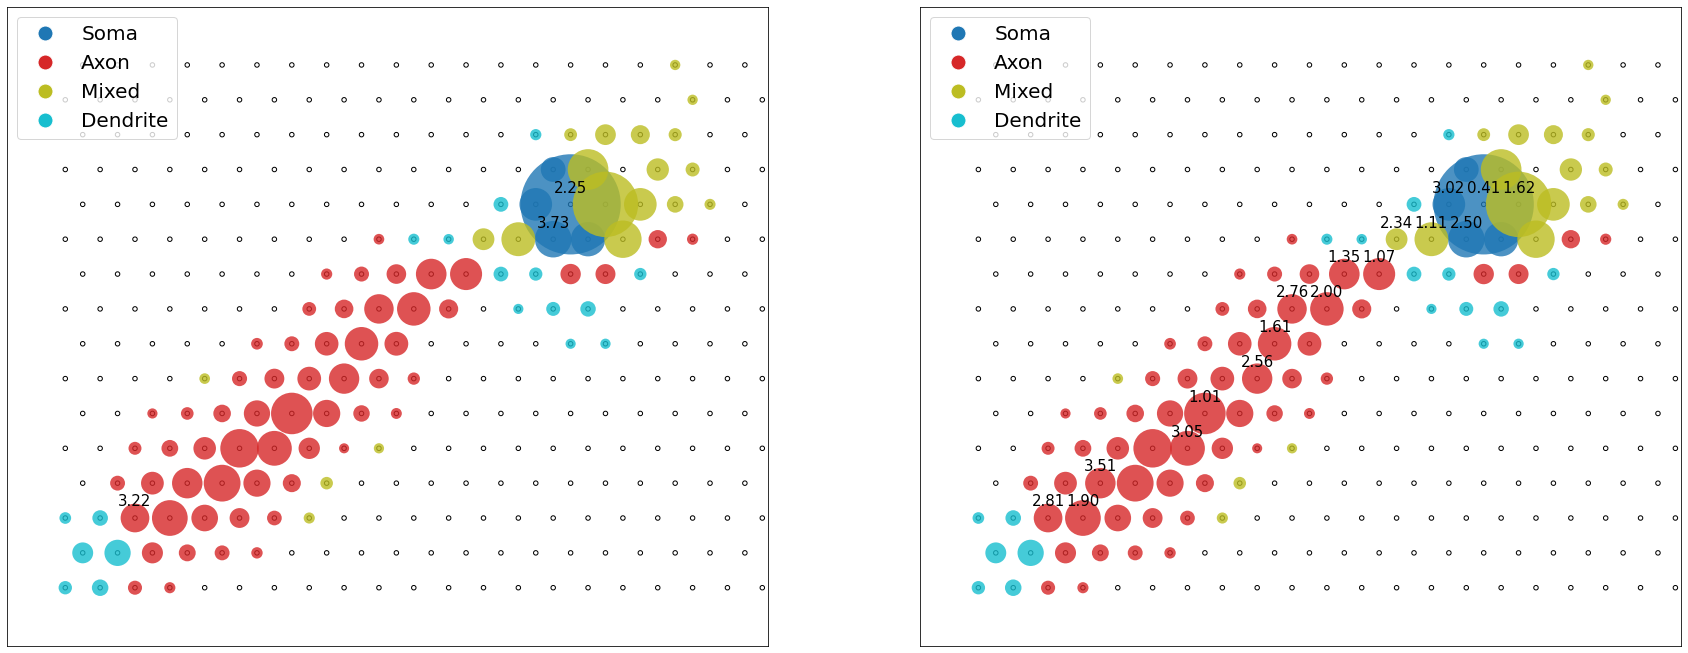

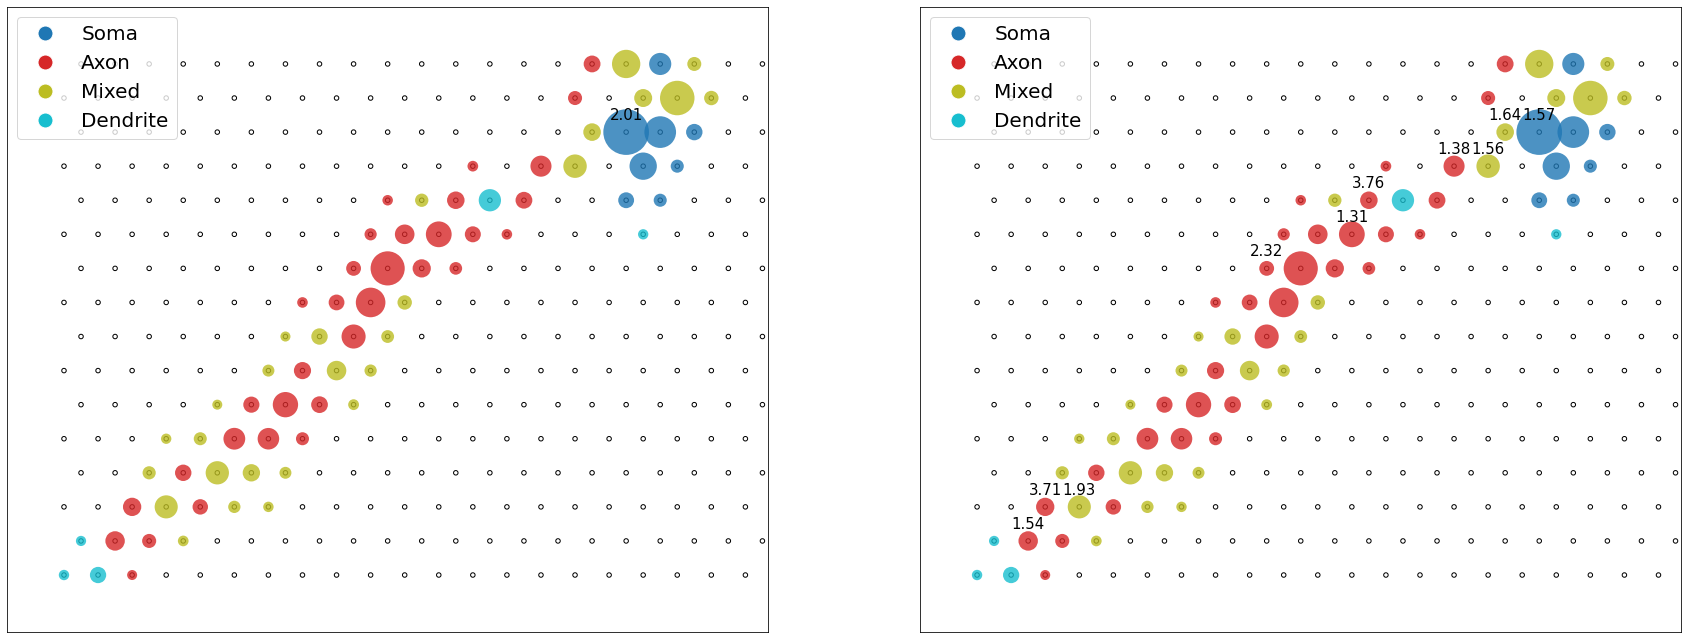

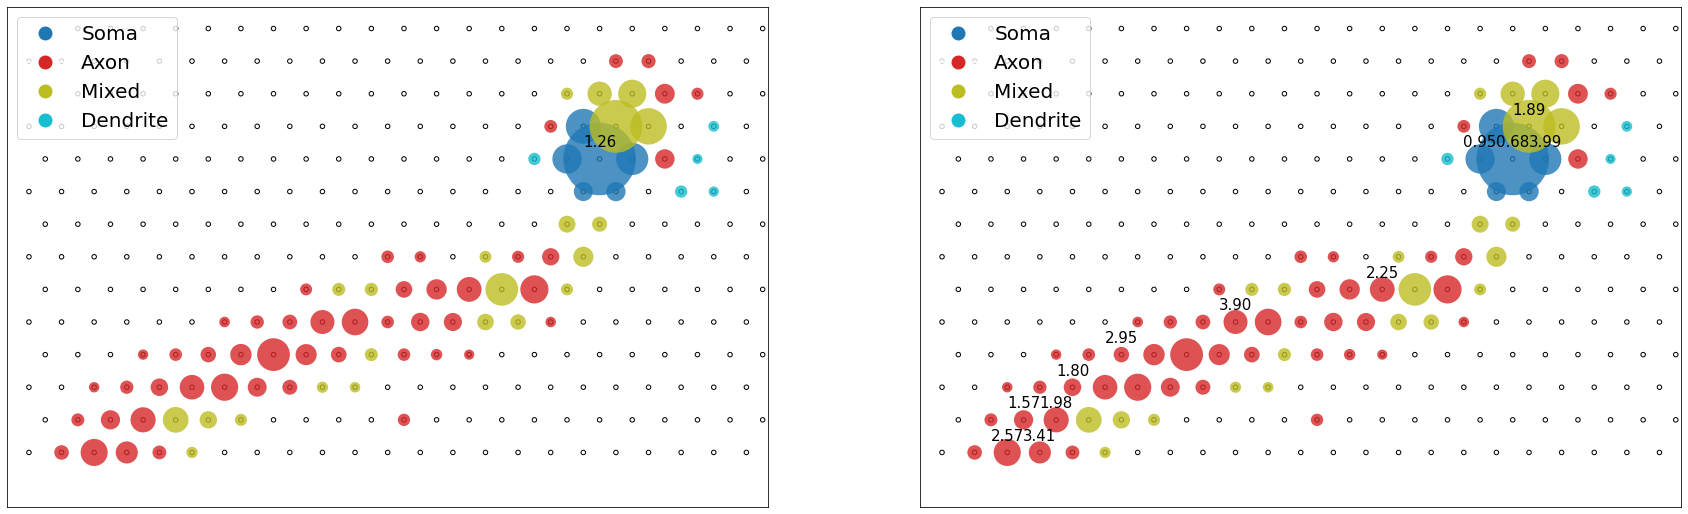

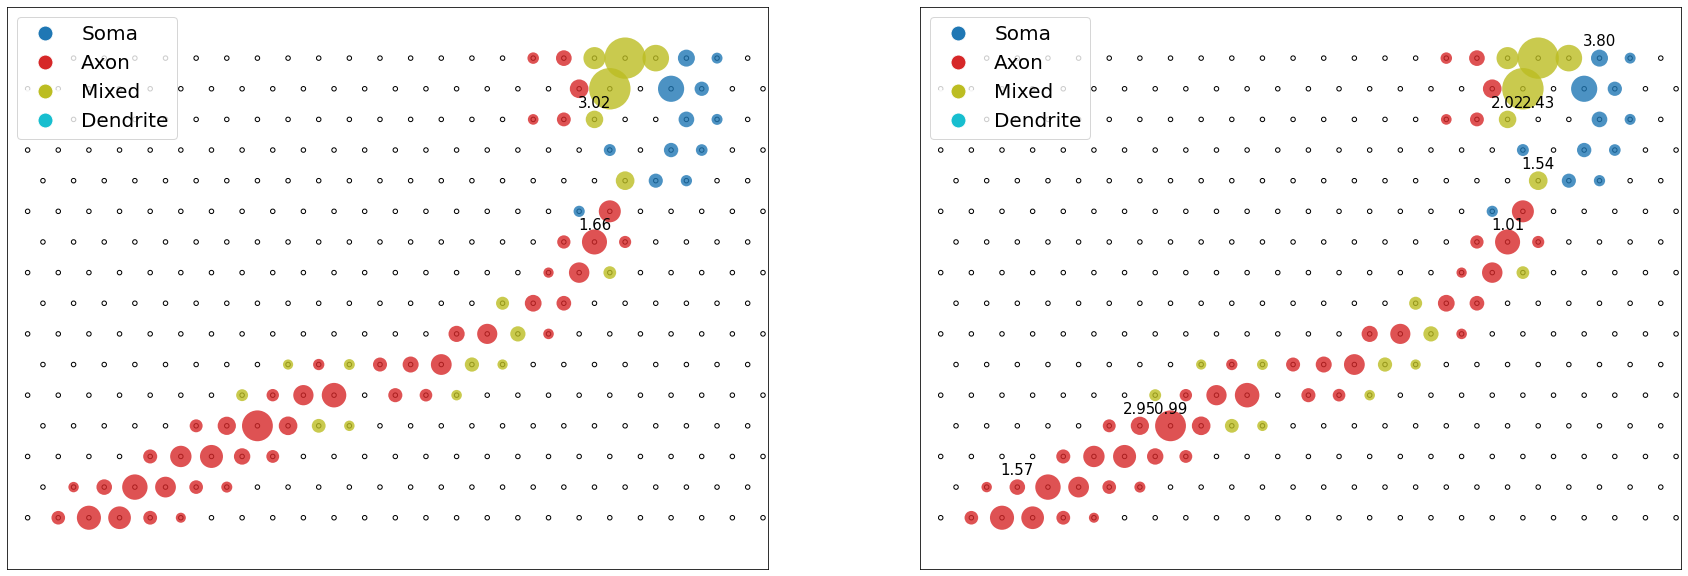

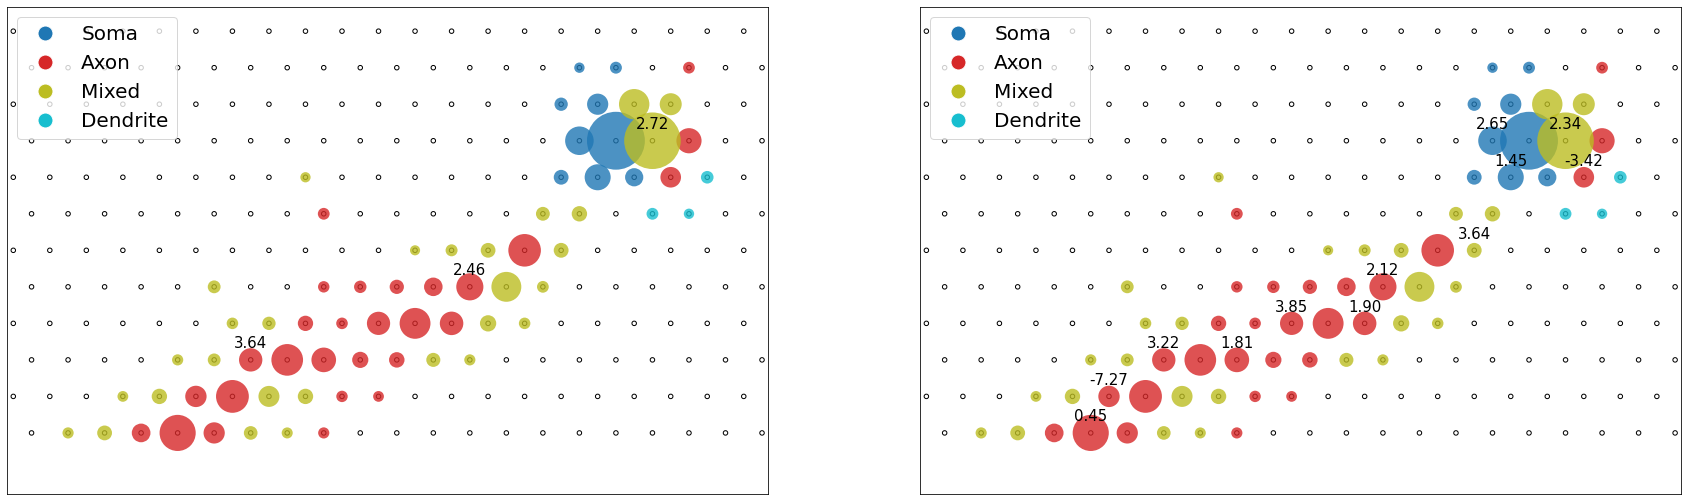

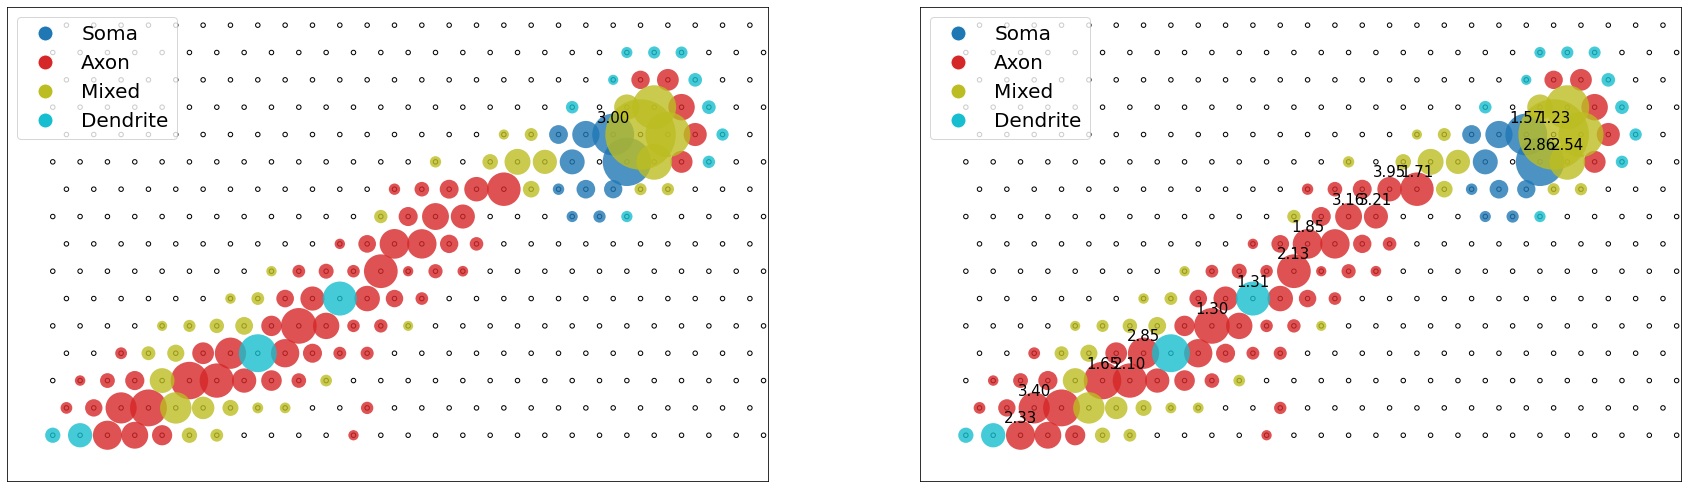

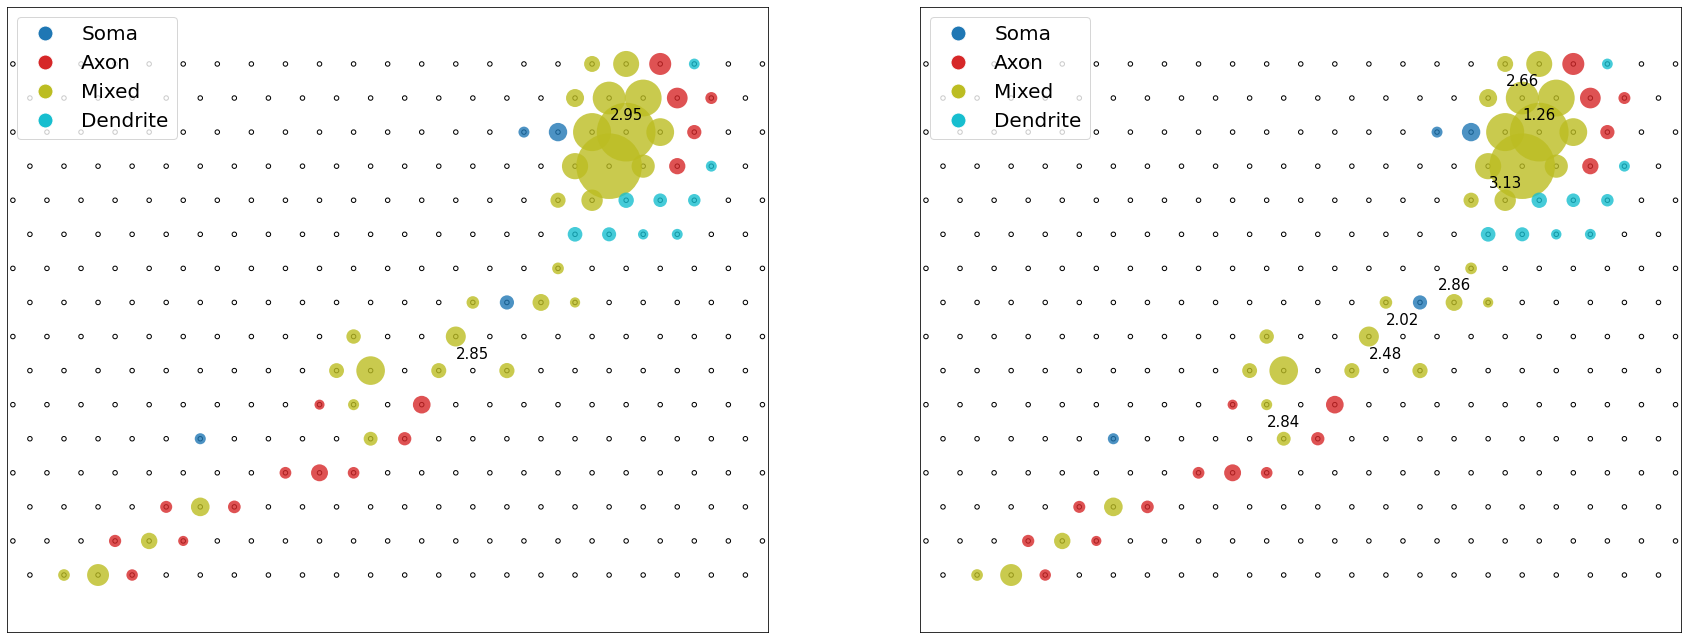

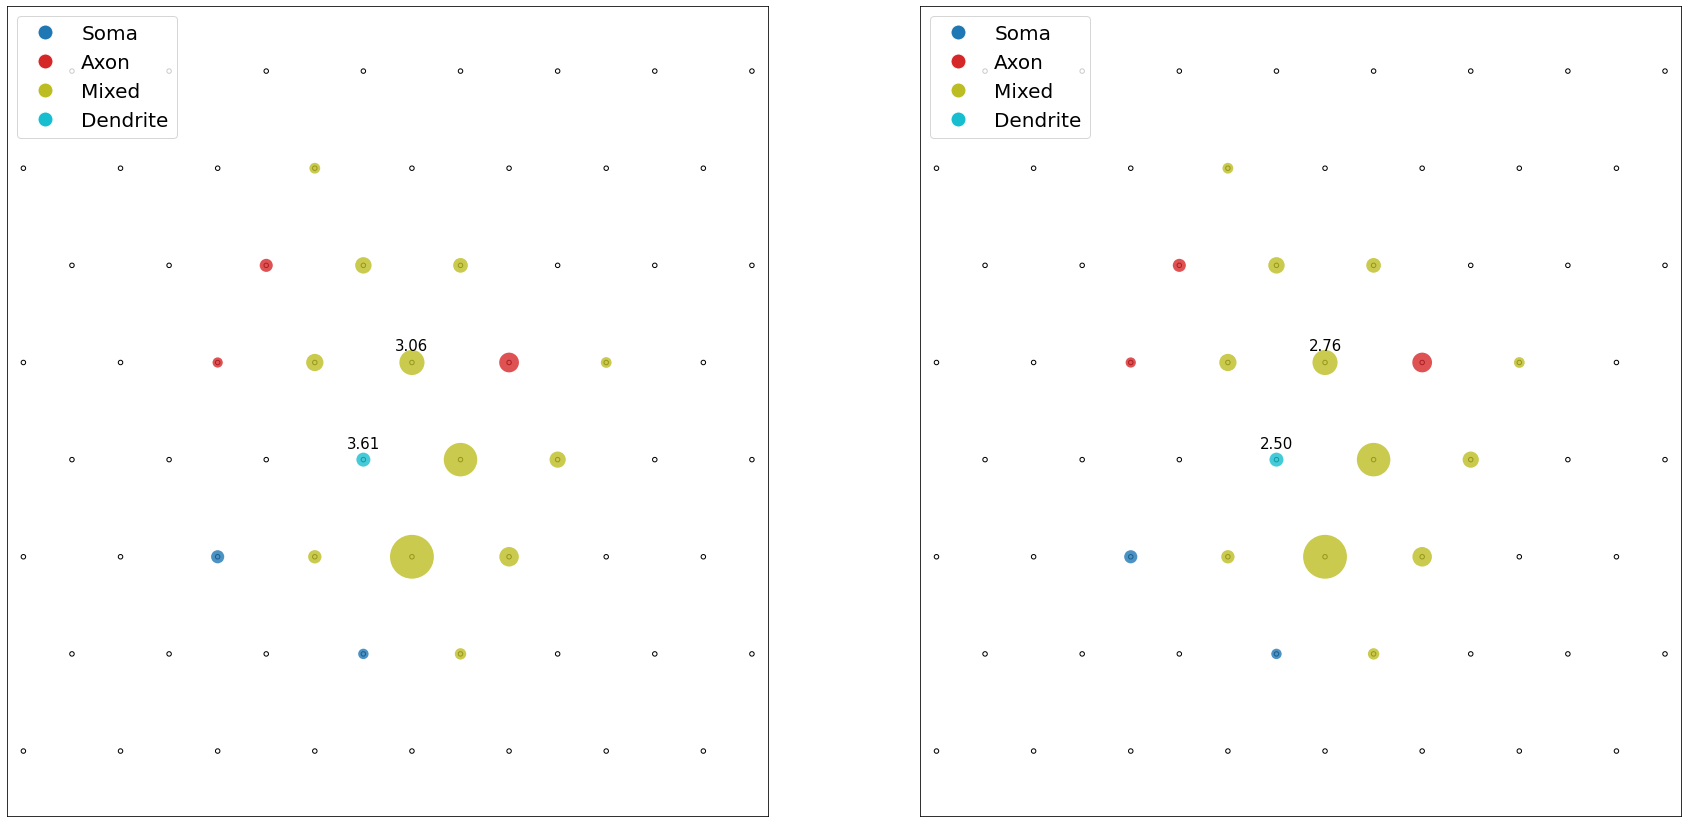

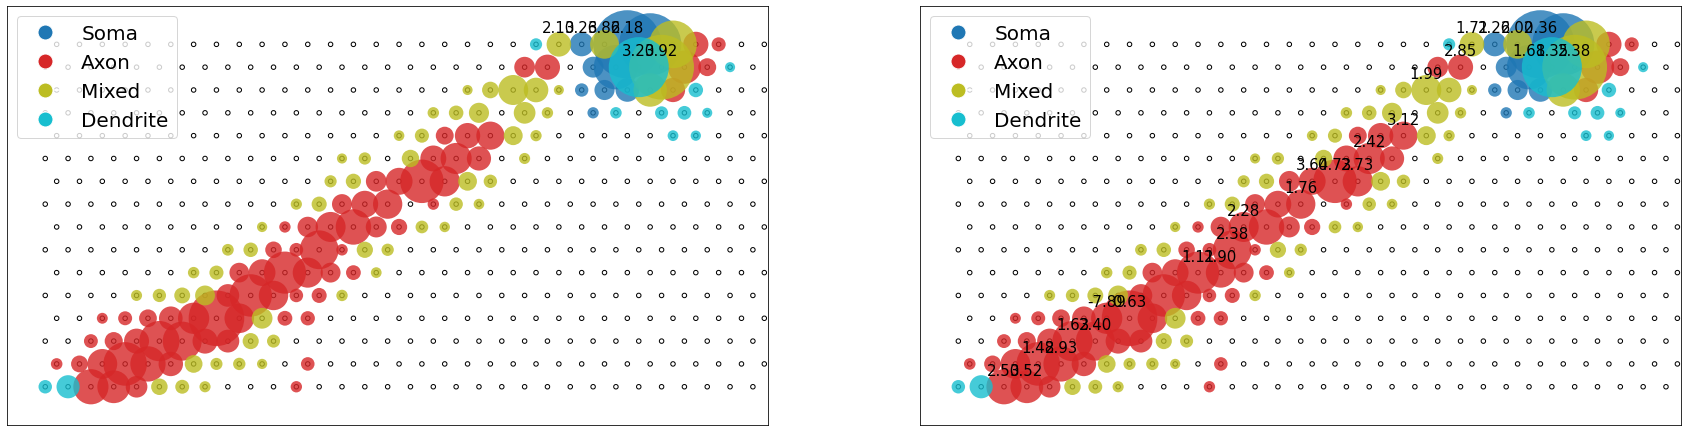

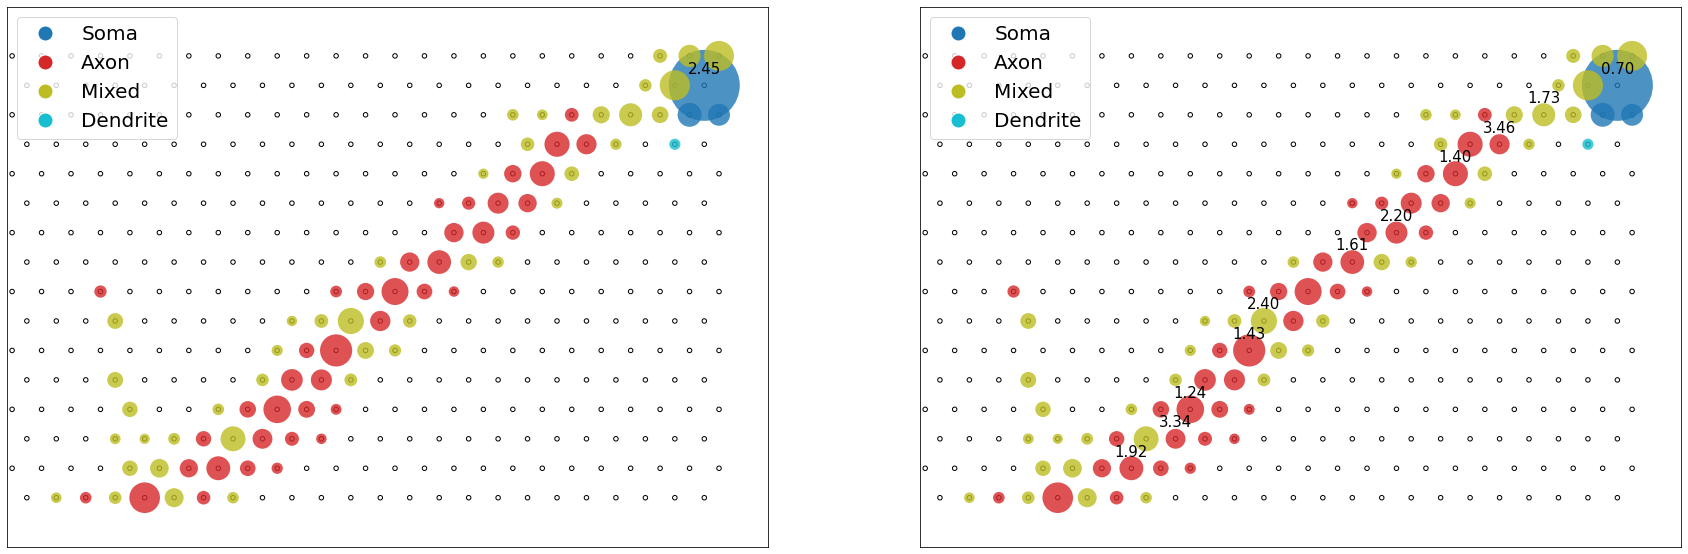

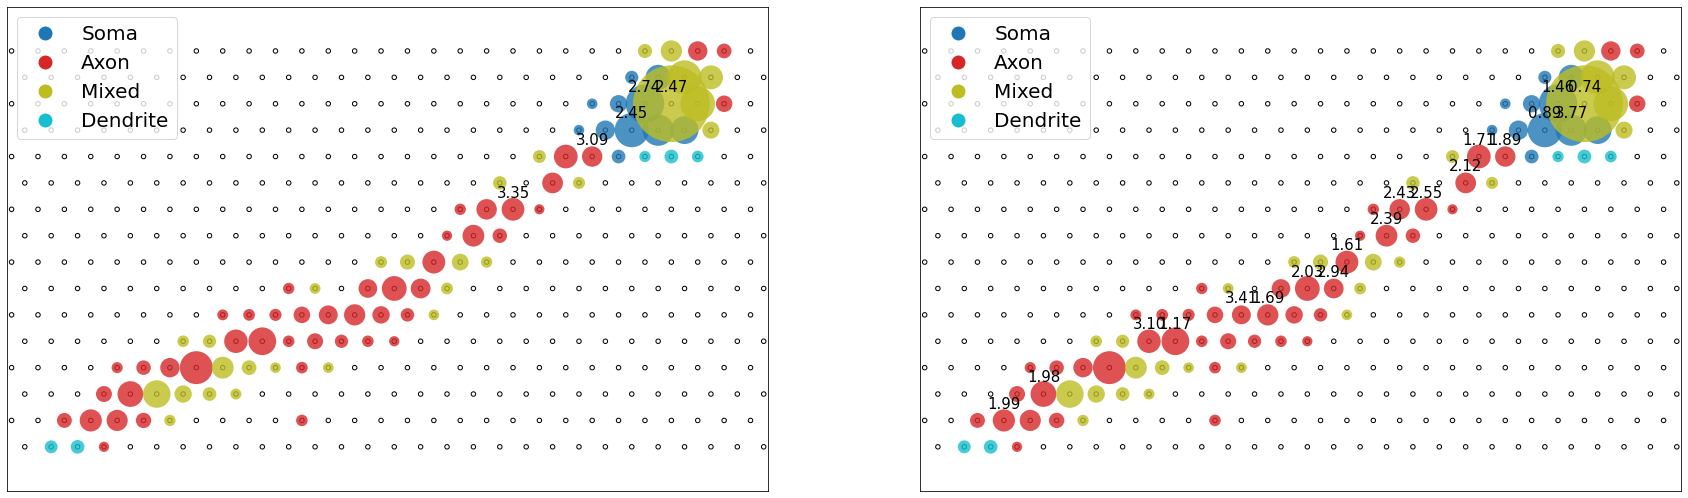

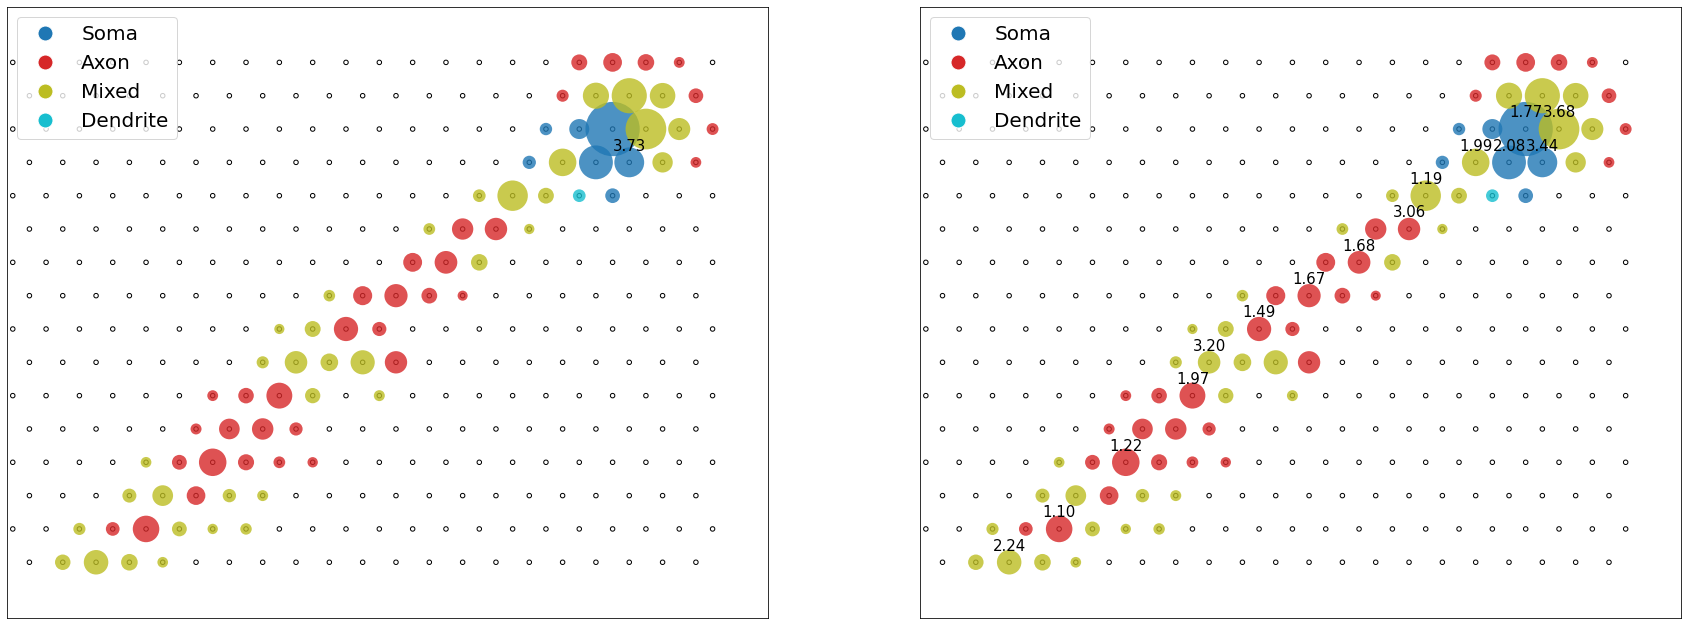

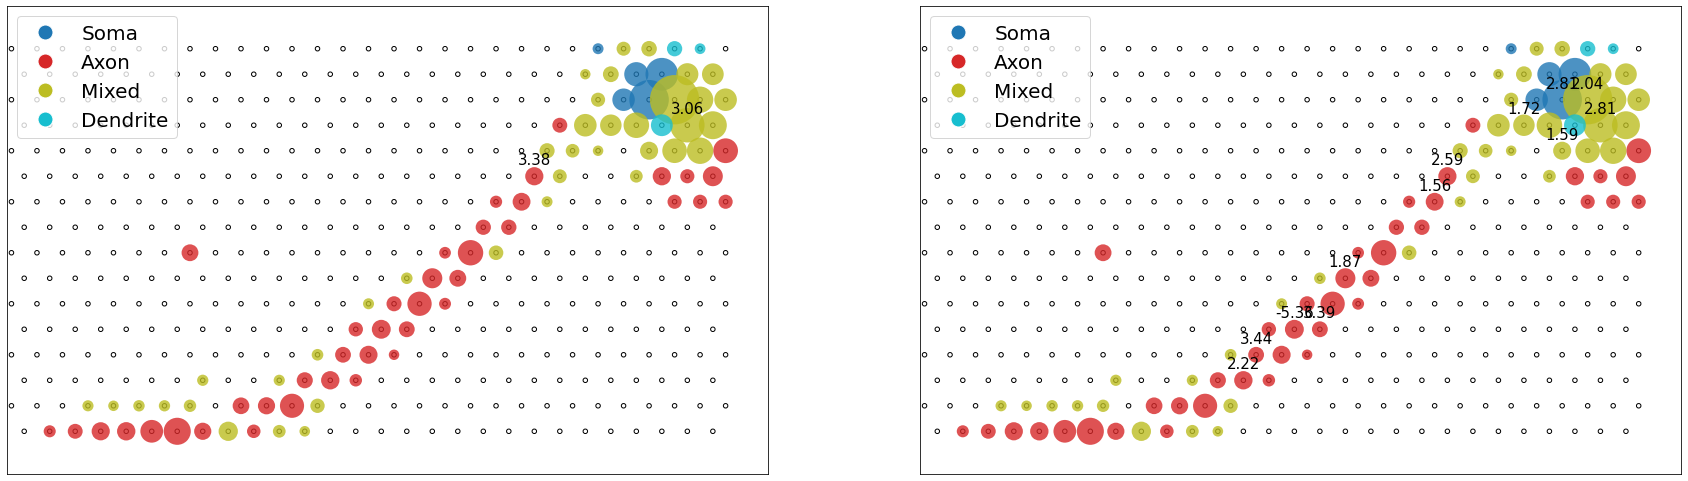

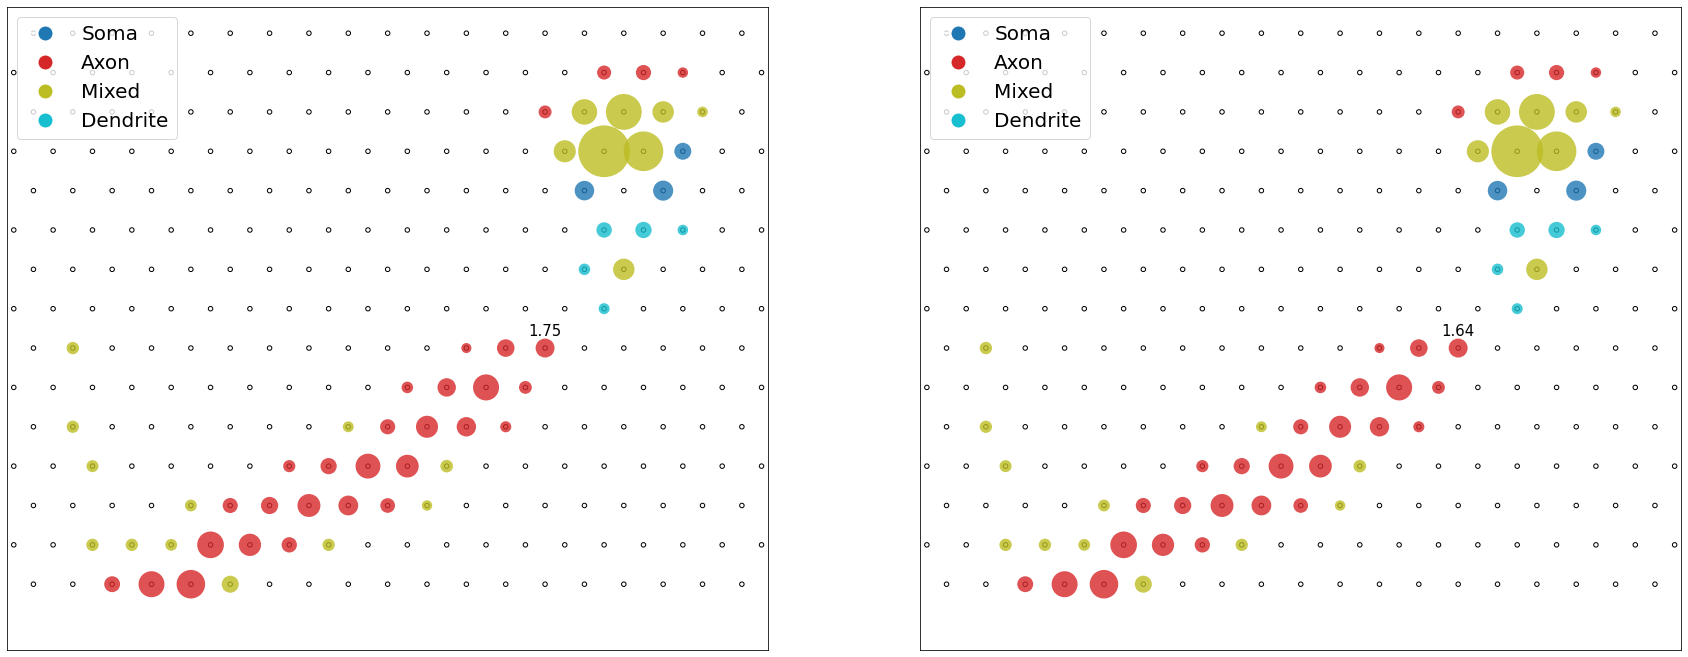

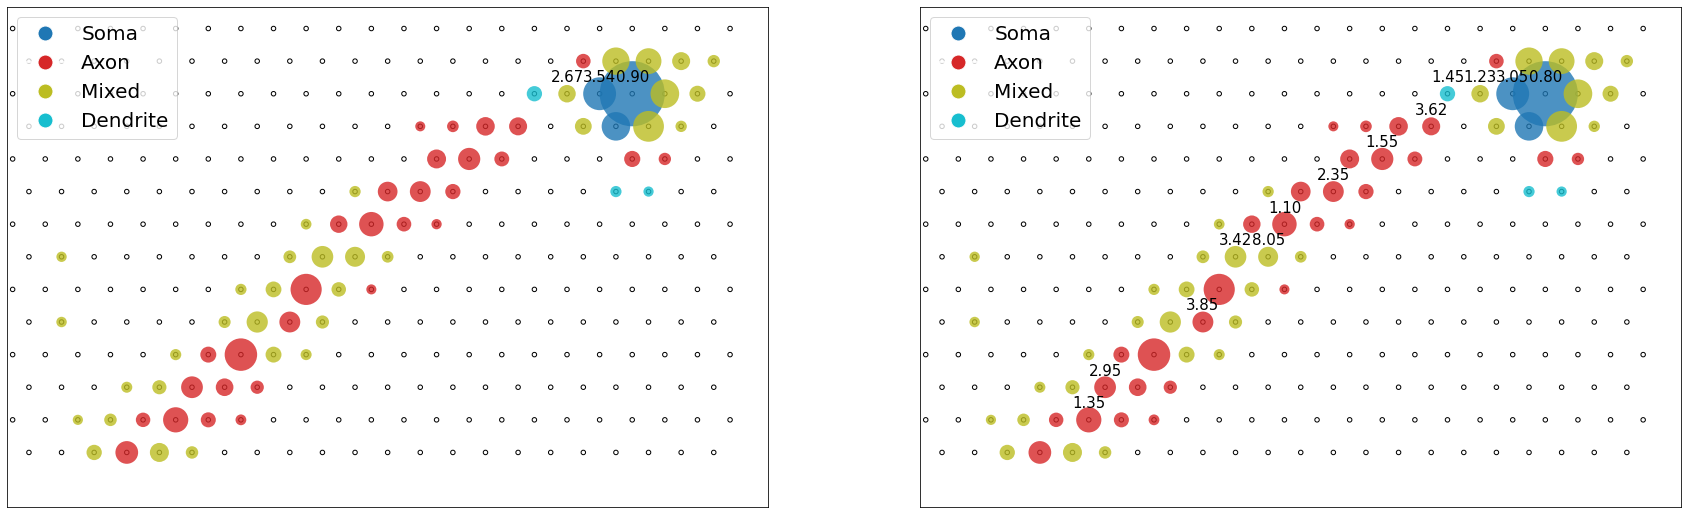

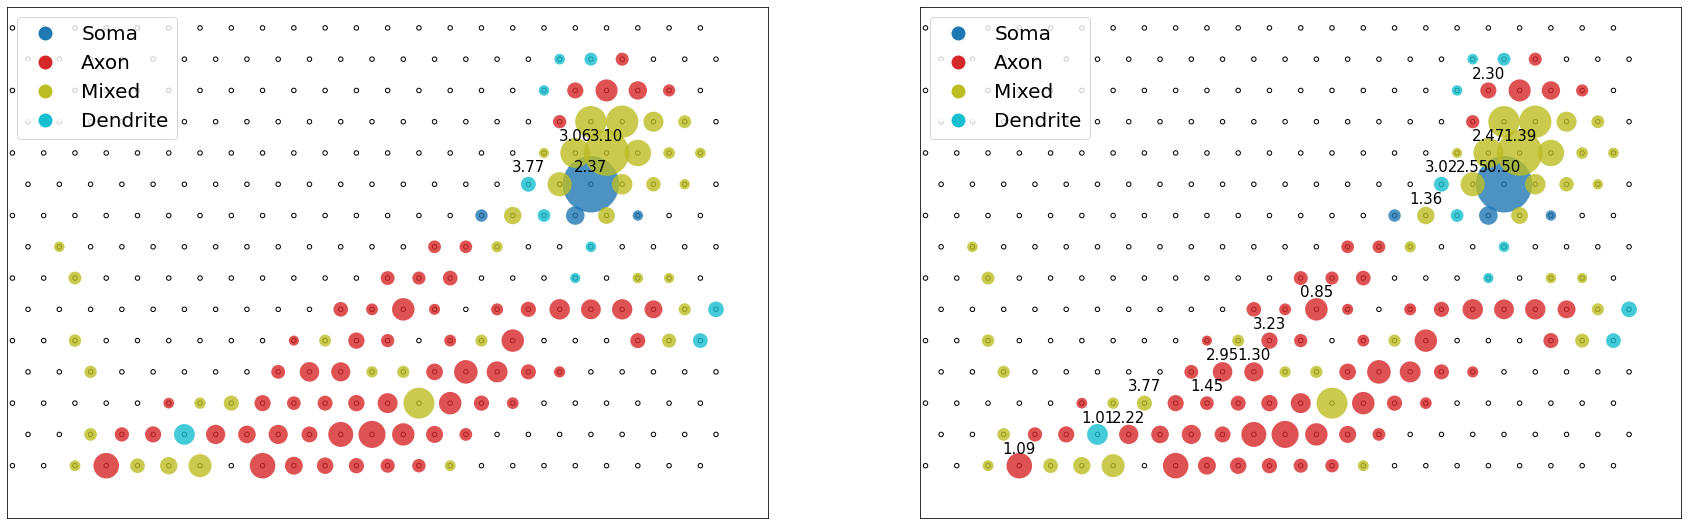

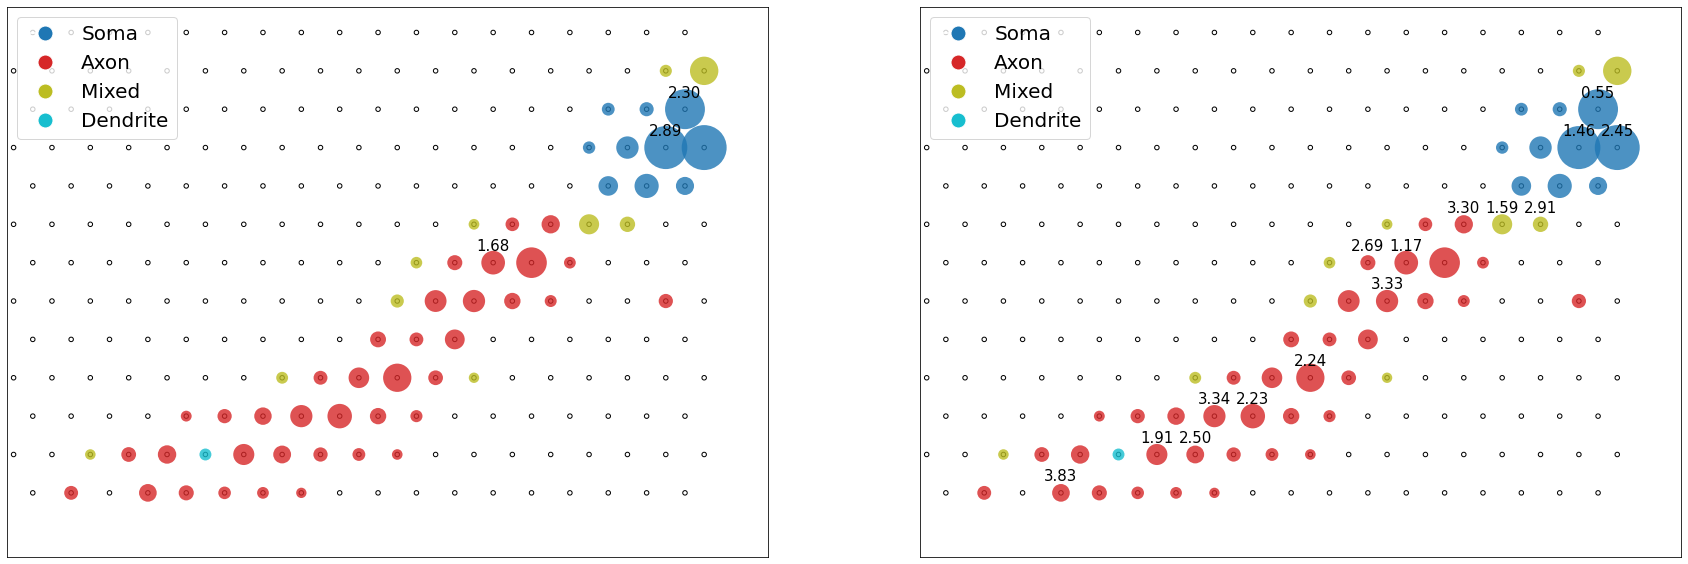

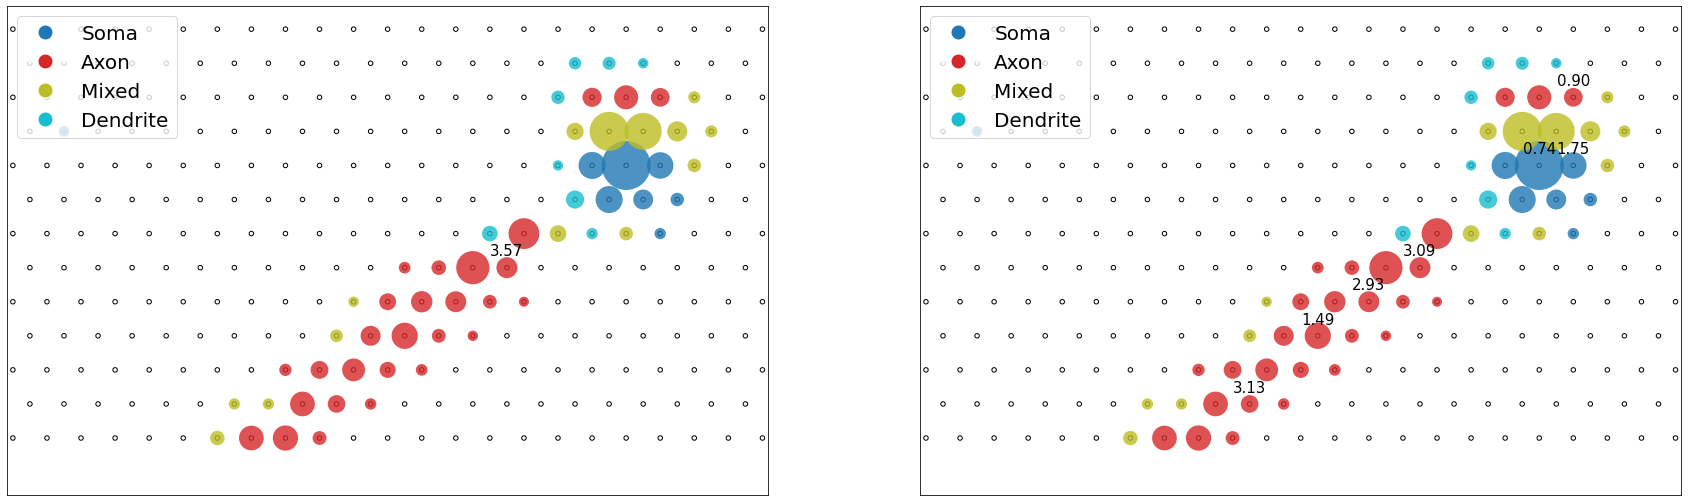

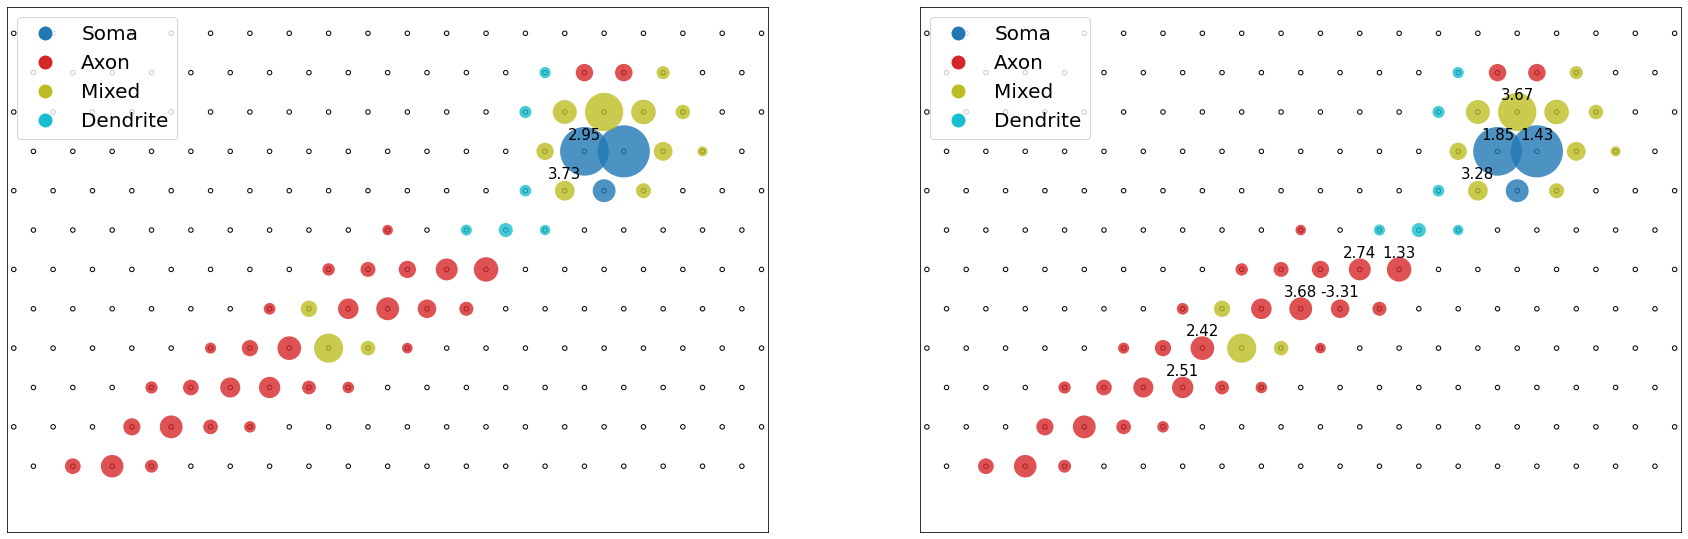

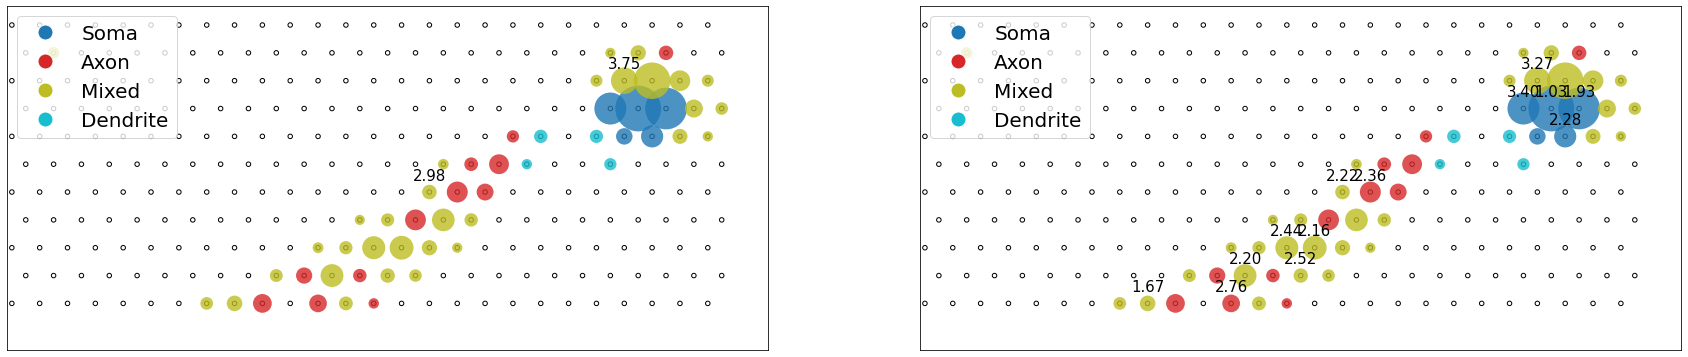

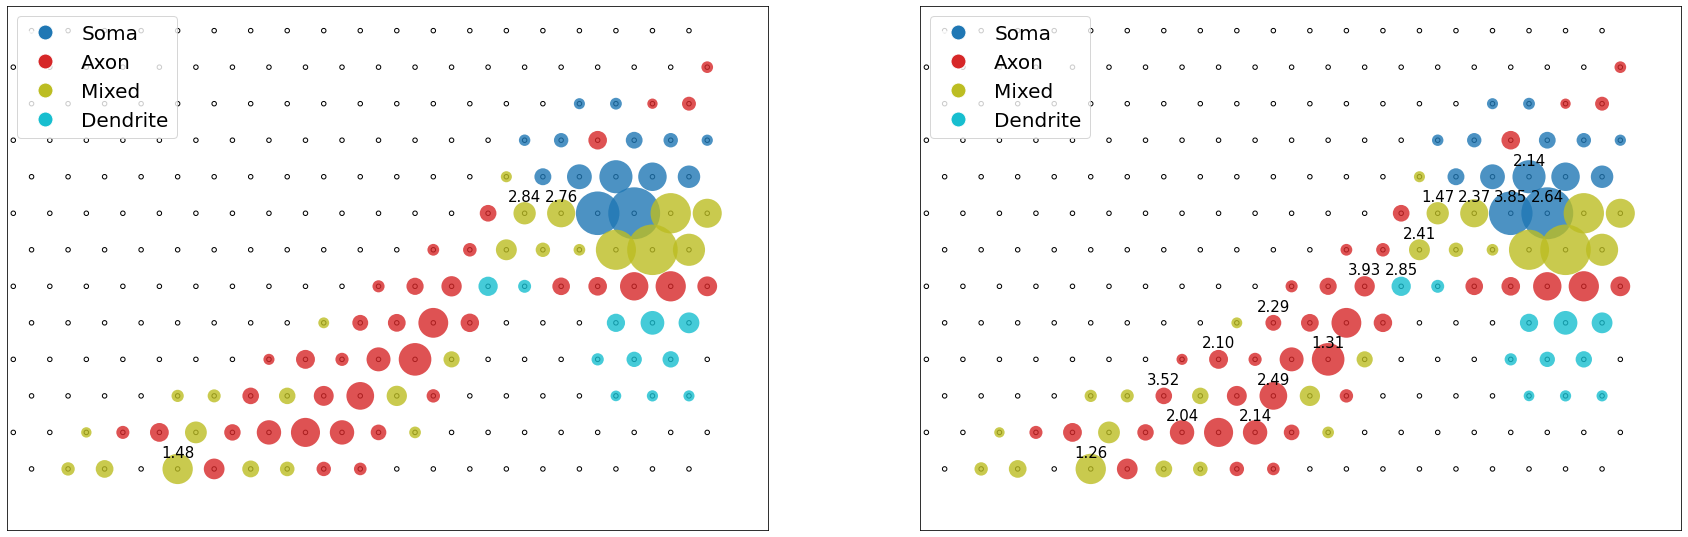

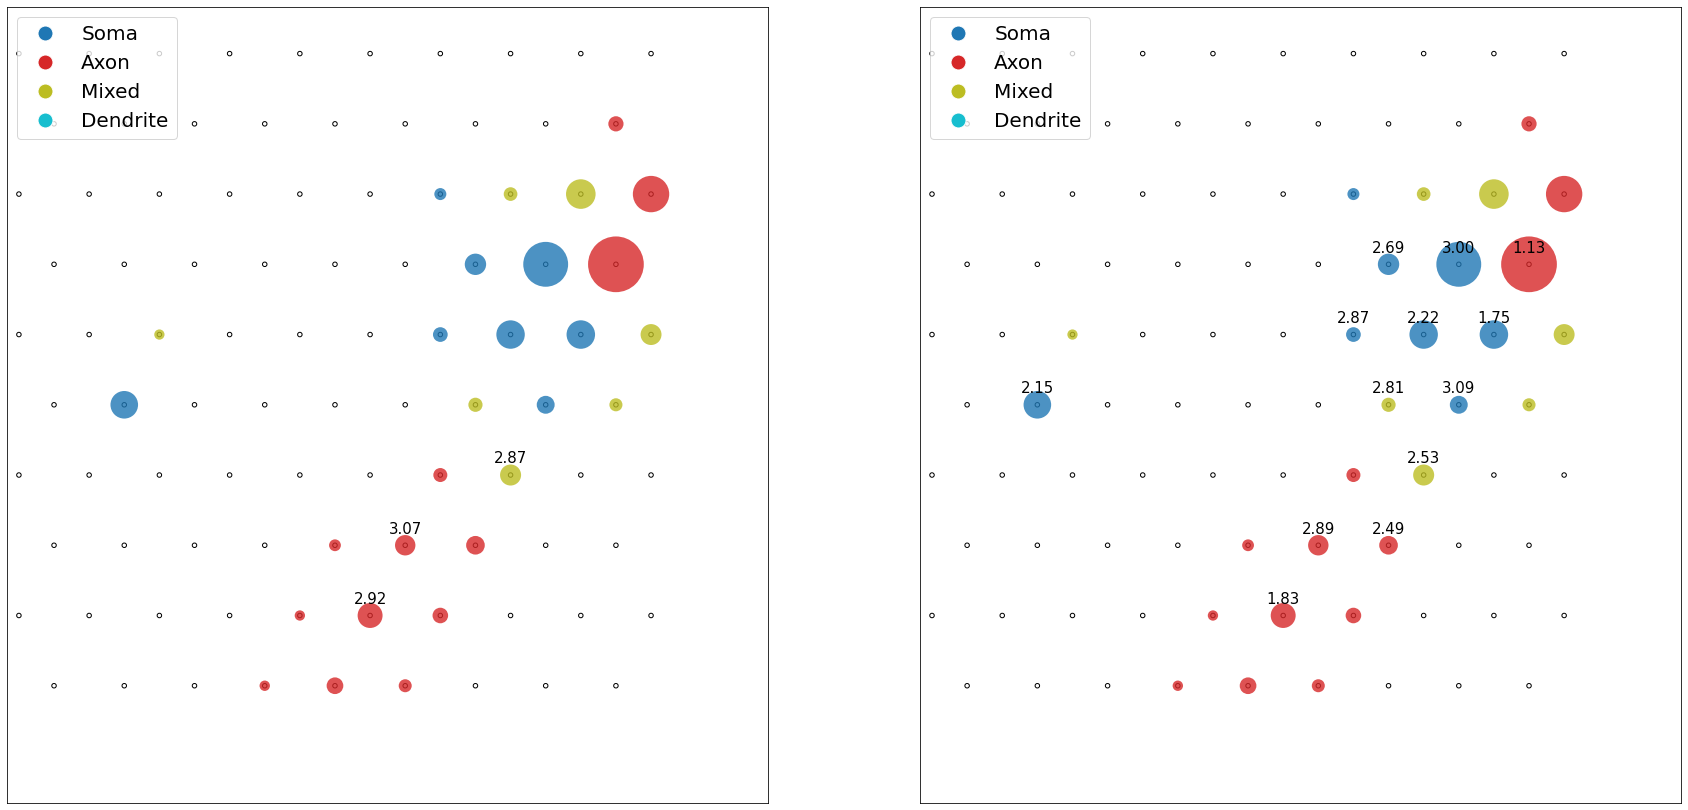

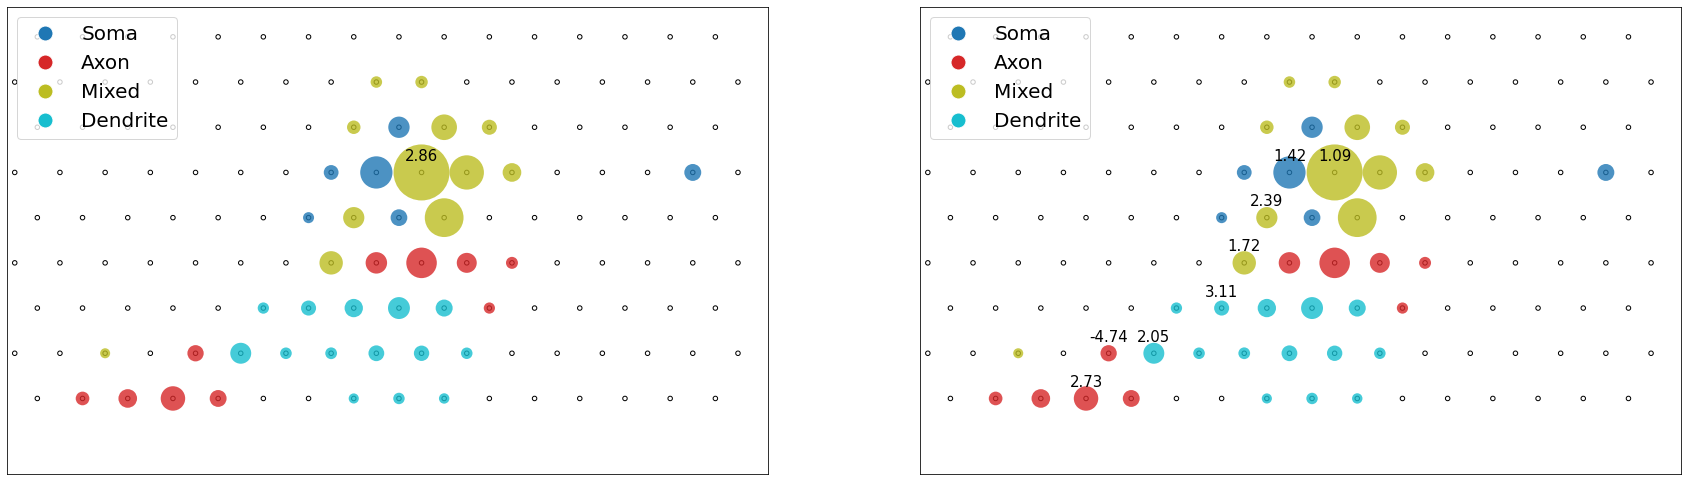

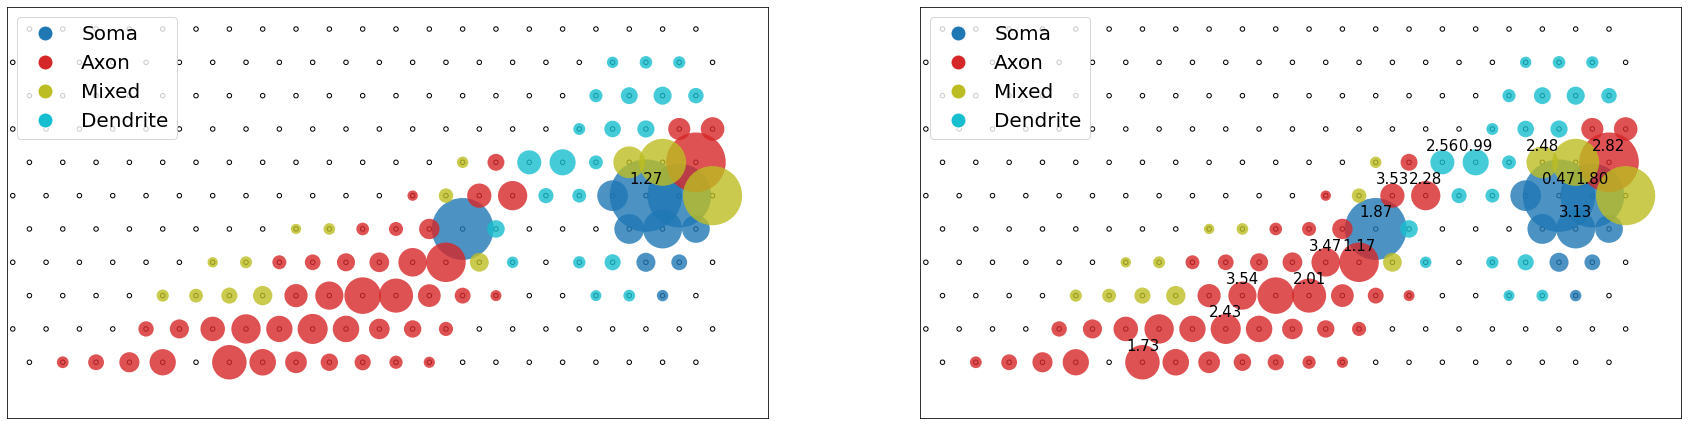

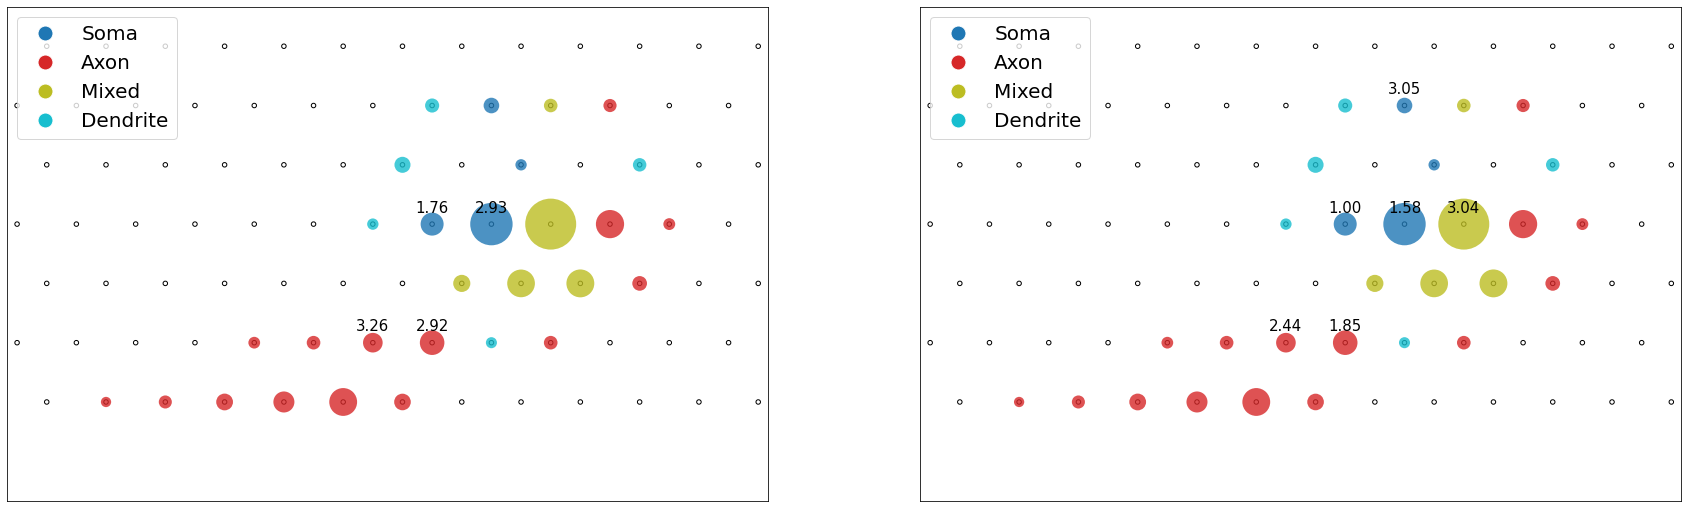

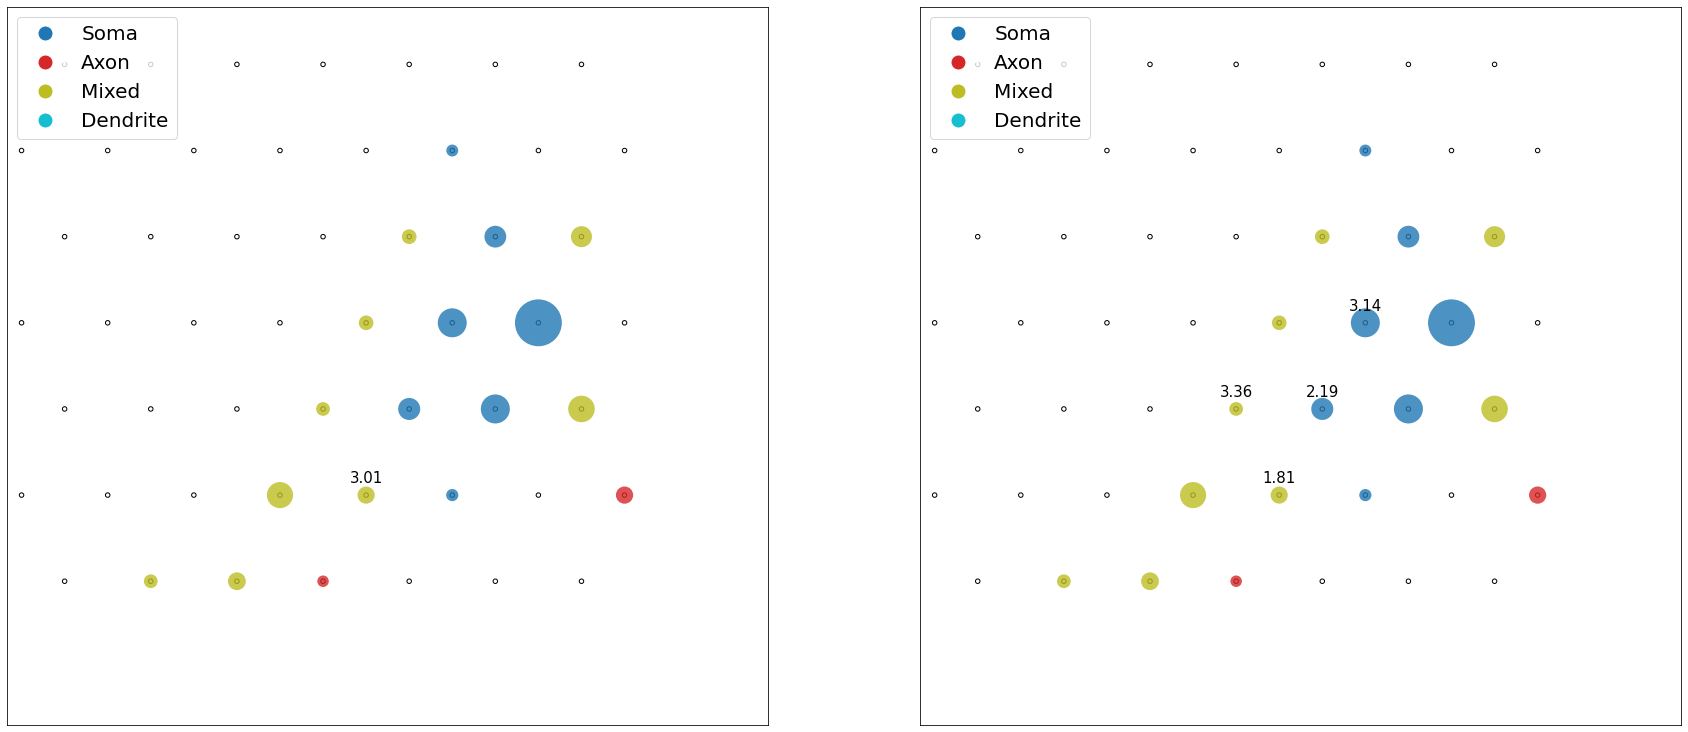

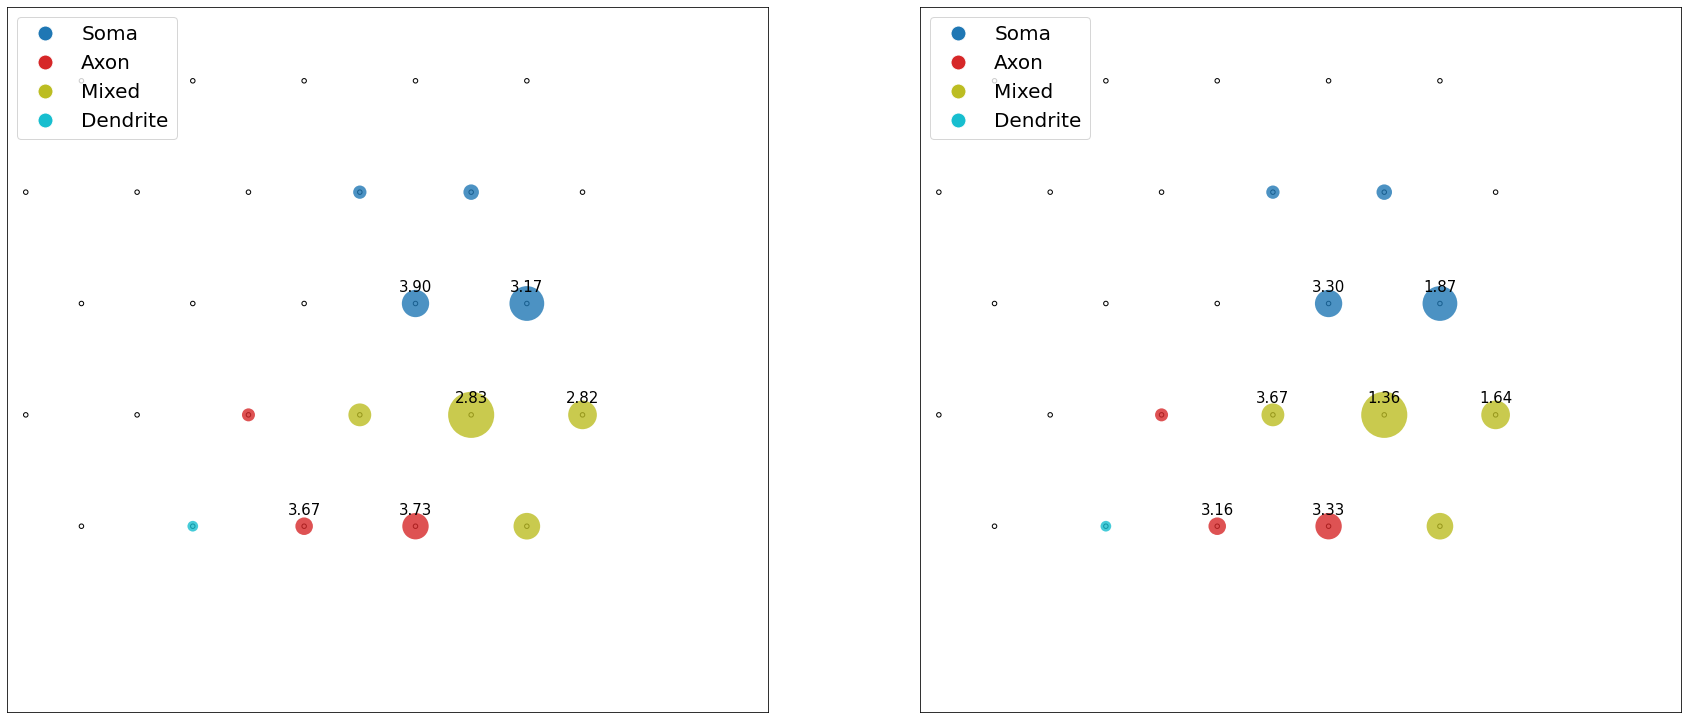

In [19]:
for cell_id in unique_cells.astype(int):

    # Extract EI for desired cell
    cell_ei = vcd.get_ei_for_cell(cell_id).ei

    # Find negative peak for each recording electrode
    ei = np.amin(cell_ei,axis=1)
    thresh = -1
    good_inds = np.argwhere(ei < thresh).flatten()
    channel_noise = vcd.channel_noise

    # Assign compartments
    soma_inds = []
    axon_inds = []
    mixed_inds = []
    dendrite_inds = []
    for elec in good_inds:
        if eil.axonorsomaRatio(cell_ei[elec,:]) == 'soma':
            soma_inds.append(elec)
        elif eil.axonorsomaRatio(cell_ei[elec,:]) == 'axon':
            axon_inds.append(elec)
        elif eil.axonorsomaRatio(cell_ei[elec,:]) == 'dendrite':
            dendrite_inds.append(elec)
        elif eil.axonorsomaRatio(cell_ei[elec,:]) == 'mixed':
            mixed_inds.append(elec)

    fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(30,15))

    for y,ax in enumerate(axs):

        # Plot electrodes
        coords = vcd.get_electrode_map()
        ax.scatter(coords[:,0], coords[:,1], facecolors='none', edgecolors='k', s=20)

        # Plot EI
        ei_size_factor = -100
        ax.scatter(coords[soma_inds,0], coords[soma_inds,1], facecolors=eil.corrColDict['soma'], 
                edgecolors='none', s=ei[soma_inds]*ei_size_factor, alpha=0.8)
        ax.scatter(coords[axon_inds,0], coords[axon_inds,1], facecolors=eil.corrColDict['axon'], 
                edgecolors='none', s=ei[axon_inds]*ei_size_factor, alpha=0.8)
        ax.scatter(coords[mixed_inds,0], coords[mixed_inds,1], facecolors=eil.corrColDict['mixed'], 
                edgecolors='none', s=ei[mixed_inds]*ei_size_factor, alpha=0.8)
        ax.scatter(coords[dendrite_inds,0], coords[dendrite_inds,1], facecolors=eil.corrColDict['dendrite'], 
                edgecolors='none', s=ei[dendrite_inds]*ei_size_factor, alpha=0.8)

        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
        ax.set_xlim([min(coords[good_inds,0])-100, max(coords[good_inds,0])+100])
        ax.set_ylim([min(coords[good_inds,1])-100, max(coords[good_inds,1])+100])
        ax.axes.set_aspect('equal')


        legend_elements = [Line2D([0], [0], marker='o', color='w', label='Soma',
                        markerfacecolor=eil.corrColDict['soma'], markersize=15),
                        Line2D([0], [0], marker='o', color='w', label='Axon',
                        markerfacecolor=eil.corrColDict['axon'], markersize=15),
                        Line2D([0], [0], marker='o', color='w', label='Mixed',
                        markerfacecolor=eil.corrColDict['mixed'], markersize=15),
                        Line2D([0], [0], marker='o', color='w', label='Dendrite',
                        markerfacecolor=eil.corrColDict['dendrite'], markersize=15)]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=20)

        if y == 0:
            # Identify from selective_stimuli which electrodes are selective for cell_id, and get the corresponding amp
            selective_subset = selective_stimuli[selective_stimuli[:,1] == cell_id]
            selective_electrodes = selective_subset[:,0].astype(int)
            selective_amps = selective_subset[:,2]

            # Label electrodes
            for z,elec in enumerate(selective_electrodes):
                num = f"{selective_amps[z]:.2f}"
                ax.annotate(num, (coords[elec-1,0],coords[elec-1,1]), textcoords='offset points', xytext=(0,12), ha='center', fontsize=15)

        elif y == 1:
            # Label electrodes
            for elec in np.arange(1,513):
                try:
                    amps, probs, slp, thr, std, success = sig.compute_sigmoid(gsort_path, pickle_path_base, cell_id, f"p{elec}", plot=False)
                    if np.isnan(thr):
                        continue
                    if success:
                        num = f"{thr:.2f}"
                        ax.annotate(num, (coords[elec-1,0],coords[elec-1,1]), textcoords='offset points', xytext=(0,12), ha='center', fontsize=15)
                except:
                    continue

    plt.show()